In [23]:
begin
    using Pkg
    Pkg.activate(joinpath(@__DIR__, "../Examples/"))
end
Threads.nthreads()
using LinearAlgebra
using SparseArrays
using GLMakie
using Revise
using BindingAndCatalysis

  Activating project at `~/Realizibility_index/BindingAndCatalysis.jl/Examples`


In [25]:
# #binding
model = let
    N = [1 1 -1]  # define stoichiometry matrix
    x_sym = [:E, :S, :C] # Optional: define species symbols
    q_sym = [:tE, :tS] # Optional: define total concentration symbols
    K_sym = [:K] # Optional: define binding constant symbols
    Bnc(N = N, x_sym=x_sym, q_sym=q_sym, K_sym=K_sym) # create Bnc model
end
find_all_vertices!(model)
summary(model)

[ Info: ---------------------Start finding all regimes--------------------
[ Info: Finished, with 4 regimes found and 4 asymptotic regimes.
[ Info: 2.Building x-neighbor regime graph...


----------Binding Network Summary:-------------
Number of species (n): 3
Number of conserved quantities (d): 2
Number of reactions (r): 1
L matrix: sparse([1, 2, 1, 2], [1, 2, 3, 3], [1, 1, 1, 1], 2, 3)
N matrix: sparse([1, 1, 1], [1, 2, 3], [1, 1, -1], 1, 3)
Direction of binding reactions: backward
Catalysis involved: No
Regimes constructed: Yes
Number of regimes: 4
  - Invertible + Asymptotic: 3
  - Singular +  Asymptotic: 1
  - Invertible +  Non-Asymptotic: 0
  - Singular +  Non-Asymptotic: 0
-----------------------------------------------


[ Info: 3.Building regime objects...
[ Info: 4.Propagating affine data and deferred nullity labels...
[ Info: 5.Calculating qK change directions on the regime graph...
[ Info: Finished.


In [26]:
logK = 0.0
logS_rg = (-6.0, 6.0)
logE_rg = (-6.0, 6.0)
pts_each_dim = 500

logS_vals = collect(range(logS_rg..., length=pts_each_dim))
logE_vals = collect(range(logE_rg..., length=pts_each_dim))

# 按 model 的 qK_symbol 顺序组装 log(q,K)，避免 [:tE,:tS,:K] / [:tS,:tE,:K] 顺序搞反
function qK_logvec(model; tS, tE, K)
    vals = Dict(:tS => tS, :tE => tE, :K => K)
    return [vals[s] for s in qK_symbol(model)]
end

# Direct numerical solution: qK -> x
data = Matrix{Vector{Float64}}(undef, pts_each_dim, pts_each_dim)
Threads.@threads for j in eachindex(logE_vals)
    startqK = qK_logvec(model; tS=first(logS_vals), tE=logE_vals[j], K=logK)
    endqK   = qK_logvec(model; tS=last(logS_vals),  tE=logE_vals[j], K=logK)

    data[:, j] .= x_traj_with_qK_change(
        model, startqK, endqK;
        input_logspace=true,
        output_logspace=true,
        npoints=pts_each_dim,
    )[2]
end

# # ROP / regime approximation
# data2 = Matrix{Vector{Float64}}(undef, pts_each_dim, pts_each_dim)
# Threads.@threads for i in eachindex(logS_vals)
#     for j in eachindex(logE_vals)
#         logqK = qK_logvec(model; tS=logS_vals[i], tE=logE_vals[j], K=logK)
#         data2[i, j] = qK2x(
#             model, logqK;
#             input_logspace=true,
#             output_logspace=true,
#             use_vtx=true,
#         )
#     end
# end

# Michaelis-Menten approximation for C
MM_C(tE, tS, K) = tE * tS / (tS + K)

MM_data = log10.(
    MM_C.(
        exp10.(logE_vals)',   # tE, row direction
        exp10.(logS_vals),    # tS, column direction
        exp10(logK),
    )
)


500×500 Matrix{Float64}:
 -12.0     -11.976    -11.9519  -11.9279   …  -0.0240485   -4.34294e-7
 -11.976   -11.9519   -11.9279  -11.9038      -4.59021e-7   0.0240476
 -11.9519  -11.9279   -11.9038  -11.8798       0.0240476    0.0480957
 -11.9279  -11.9038   -11.8798  -11.8557       0.0480957    0.0721438
 -11.9038  -11.8798   -11.8557  -11.8317       0.0721437    0.0961918
 -11.8798  -11.8557   -11.8317  -11.8076   …   0.0961918    0.12024
 -11.8557  -11.8317   -11.8076  -11.7836       0.12024      0.144288
 -11.8317  -11.8076   -11.7836  -11.7595       0.144288     0.168336
 -11.8076  -11.7836   -11.7595  -11.7355       0.168336     0.192384
 -11.7836  -11.7595   -11.7355  -11.7114       0.192384     0.216432
 -11.7595  -11.7355   -11.7114  -11.6874   …   0.216432     0.24048
 -11.7355  -11.7114   -11.6874  -11.6633       0.24048      0.264528
 -11.7114  -11.6874   -11.6633  -11.6393       0.264528     0.288576
   ⋮                                       ⋱               
  -6.0      -5

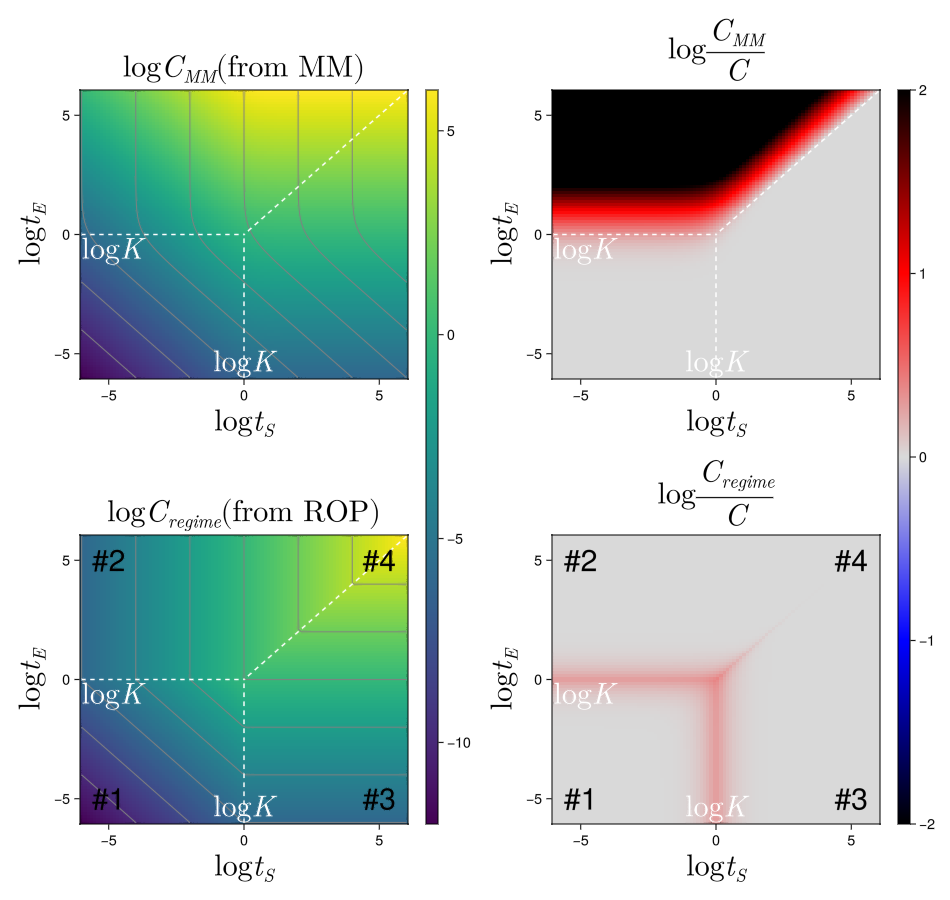

In [16]:



# ---------------- plot ----------------

xlo, xhi = logS_rg
ylo, yhi = logE_rg

line1 = Point2d.([[xlo, logK], [logK, logK]])
line2 = Point2d.([[logK, ylo], [logK, logK]])
line3 = Point2d.([[xhi, yhi], [logK, logK]])
txtsize = 30

add_line(ax) = begin
    for line in (line1, line2, line3)
        lines!(ax, line, color=:white, linestyle=:dash)
    end
end

add_text(ax) = begin
    text!(ax, Point(logK, ylo);
        text=L"\log K",
        align=(:center, :bottom),
        color=:white,
        rotation=0,
        fontsize=txtsize,
    )
    text!(ax, Point(xlo, logK);
        text=L"\log K",
        align=(:left, :top),
        color=:white,
        rotation=0,
        fontsize=txtsize,
    )
end

add_regime(ax) = begin
    text!(ax, Point(-5, -5); text="#1", align=(:center, :center), color=:black, fontsize=txtsize)
    text!(ax, Point(-5,  5); text="#2", align=(:center, :center), color=:black, fontsize=txtsize)
    text!(ax, Point( 5, -5); text="#3", align=(:center, :center), color=:black, fontsize=txtsize)
    text!(ax, Point( 5,  5); text="#4", align=(:center, :center), color=:black, fontsize=txtsize)
end

begin
    neg = cgrad([:blue, :black], 100; rev=true).colors.colors
    mid = cgrad([:blue, "#D9D9D9", :red], 200).colors.colors
    pos = cgrad([:red, :black], 100).colors.colors
    my_cmap = vcat(neg, mid, pos)
end

fig = Figure(size=(950, 900), backgroundcolor=:white)

ax1 = Axis(fig[1, 1],
    ylabel=L"\log t_E",
    xlabel=L"\log t_S",
    title=L"\log C_{MM}(\text{from MM})",
    titlesize=txtsize,
    xlabelsize=txtsize,
    ylabelsize=txtsize,
)

min_val, max_val = extrema(MM_data)
hm = heatmap!(ax1, logS_vals, logE_vals, MM_data;
    colormap=:viridis,
    colorrange=(min_val, max_val),
)
contour!(ax1, logS_vals, logE_vals, MM_data'; color=:gray, levels=-30:2:30)
add_line(ax1)
add_text(ax1)

ax2 = Axis(fig[2, 1],
    ylabel=L"\log t_E",
    xlabel=L"\log t_S",
    title=L"\log C_{regime}(\text{from ROP})",
    titlesize=txtsize,
    xlabelsize=txtsize,
    ylabelsize=txtsize,
)

C_regime = data2 .|> x -> x[3]
heatmap!(ax2, logS_vals, logE_vals, C_regime;
    colormap=:viridis,
    colorrange=(min_val, max_val),
)
contour!(ax2, logS_vals, logE_vals, C_regime'; color=:gray, levels=-30:2:30)
add_line(ax2)
add_text(ax2)
add_regime(ax2)

Colorbar(fig[1:2, 2], hm)

ax3 = Axis(fig[1, 3],
    ylabel=L"\log t_E",
    xlabel=L"\log t_S",
    title=L"\log \frac{C_{MM}}{C}",
    titlesize=txtsize,
    xlabelsize=txtsize,
    ylabelsize=txtsize,
)

C_direct = data .|> x -> x[3]
diff_data = MM_data .- C_direct
max_diff = 2

hm2 = heatmap!(ax3, logS_vals, logE_vals, diff_data;
    colormap=my_cmap,
    colorrange=(-max_diff, max_diff),
)
add_line(ax3)
add_text(ax3)

ax4 = Axis(fig[2, 3],
    ylabel=L"\log t_E",
    xlabel=L"\log t_S",
    title=L"\log \frac{C_{regime}}{C}",
    titlesize=txtsize,
    xlabelsize=txtsize,
    ylabelsize=txtsize,
)

diff_data2 = (data2 .- data) .|> x -> x[3]
heatmap!(ax4, logS_vals, logE_vals, diff_data2;
    colormap=my_cmap,
    colorrange=(-max_diff, max_diff),
)
add_text(ax4)
add_regime(ax4)

Colorbar(fig[1:2, 4], colormap=my_cmap, colorrange=(-max_diff, max_diff))

fig

In [31]:
# begin
#     neg = cgrad([:blue, :black], 100; rev=true).colors.colors
#     mid = cgrad([:blue, "#D9D9D9", :red], 200).colors.colors
#     pos = cgrad([:red, :black], 100).colors.colors
#     my_cmap = vcat(neg, mid, pos)
# end
my_cmap = :seismic

:seismic

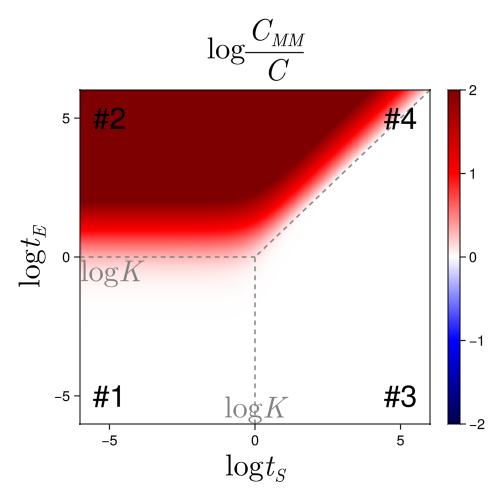

In [36]:
# ---------------- plot ----------------

xlo, xhi = logS_rg
ylo, yhi = logE_rg

line1 = Point2d.([[xlo, logK], [logK, logK]])
line2 = Point2d.([[logK, ylo], [logK, logK]])
line3 = Point2d.([[xhi, yhi], [logK, logK]])
txtsize = 30

add_line(ax) = begin
    for line in (line1, line2, line3)
        lines!(ax, line, color=:gray, linestyle=:dash)
    end
end

add_text(ax) = begin
    text!(ax, Point(logK, ylo);
        text=L"\log K",
        align=(:center, :bottom),
        color=:gray,
        rotation=0,
        fontsize=txtsize,
    )
    text!(ax, Point(xlo, logK);
        text=L"\log K",
        align=(:left, :top),
        color=:gray,
        rotation=0,
        fontsize=txtsize,
    )
end

add_regime(ax) = begin
    text!(ax, Point(-5, -5); text="#1", align=(:center, :center), color=:black, fontsize=txtsize)
    text!(ax, Point(-5,  5); text="#2", align=(:center, :center), color=:black, fontsize=txtsize)
    text!(ax, Point( 5, -5); text="#3", align=(:center, :center), color=:black, fontsize=txtsize)
    text!(ax, Point( 5,  5); text="#4", align=(:center, :center), color=:black, fontsize=txtsize)
end

# begin
#     neg = cgrad([:blue, :black], 100; rev=true).colors.colors
#     mid = cgrad([:blue, "#D9D9D9", :red], 200).colors.colors
#     pos = cgrad([:red, :black], 100).colors.colors
#     my_cmap = vcat(neg, mid, pos)
# end

fig = Figure(size=(500, 500), backgroundcolor=:white)

# ---------------- first plot ----------------

# ax1 = Axis(fig[1, 1],
#     ylabel=L"\log t_E",
#     xlabel=L"\log t_S",
#     title=L"\log C_{MM}(\text{from MM})",
#     titlesize=txtsize,
#     xlabelsize=txtsize,
#     ylabelsize=txtsize,
# )

# min_val, max_val = extrema(MM_data)

# hm = heatmap!(ax1, logS_vals, logE_vals, MM_data;
#     colormap=:viridis,
#     colorrange=(min_val, max_val),
# )

# contour!(ax1, logS_vals, logE_vals, MM_data';
#     color=:gray,
#     levels=-30:2:30,
# )

# add_line(ax1)
# add_text(ax1)
# # add_regime(ax1)

# Colorbar(fig[1, 2], hm)

# ---------------- second plot ----------------

ax2 = Axis(fig[1, 1],
    ylabel=L"\log t_E",
    xlabel=L"\log t_S",
    title=L"\log \frac{C_{MM}}{C}",
    titlesize=txtsize,
    xlabelsize=txtsize,
    ylabelsize=txtsize,
)

C_direct = data .|> x -> x[3]
diff_data = MM_data .- C_direct
max_diff = 2

hm2 = heatmap!(ax2, logS_vals, logE_vals, diff_data;
    colormap=my_cmap,
    colorrange=(-max_diff, max_diff),
)

add_line(ax2)
add_text(ax2)
add_regime(ax2)

Colorbar(fig[1, 2], hm2)

fig

In [37]:
save("MM_compare_with_real.png", fig,px_per_unit=3)

In [38]:
model1, model2 = let
    q_sym = [:qE, :qS]
    K_sym1 = [:K₁, :K₂]
    K_sym2 = [:K_S, :K_E]
    x_sym1 = [:E, :S, :C₁, :C₂]
    x_sym2 = [:E, :S, :C_S, :C₂]
    N1 =     [1  1  -1  0;
            0  1  1  -1]
    N2 =     [0  2  -1  0;
            1  0  1  -1]
    model1 = Bnc(N=N1, x_sym=x_sym1, q_sym=q_sym, K_sym=K_sym1)
    model2 = Bnc(N=N2, x_sym=x_sym2, q_sym=q_sym, K_sym=K_sym2)
    model1, model2
end

find_all_regimes!(model1)
find_all_regimes!(model2)
summary(model1)
summary(model2)

[ Info: ---------------------Start finding all regimes--------------------
[ Info: Finished, with 8 regimes found and 7 asymptotic regimes.
[ Info: 2.Building x-neighbor regime graph...
[ Info: 3.Building regime objects...
[ Info: 4.Propagating affine data and deferred nullity labels...


----------Binding Network Summary:-------------
Number of species (n): 4
Number of conserved quantities (d): 2
Number of reactions (r): 2
L matrix: sparse([1, 2, 1, 2, 1, 2], [1, 2, 3, 3, 4, 4], [1, 1, 1, 1, 1, 2], 2, 4)
N matrix: sparse([1, 1, 2, 1, 2, 2], [1, 2, 2, 3, 3, 4], [1, 1, 1, -1, 1, -1], 2, 4)
Direction of binding reactions: forward
Catalysis involved: No
Regimes constructed: Yes
Number of regimes: 8
  - Invertible + Asymptotic: 5
  - Singular +  Asymptotic: 2
  - Invertible +  Non-Asymptotic: 1
  - Singular +  Non-Asymptotic: 0
-----------------------------------------------
----------Binding Network Summary:-------------
Number of species (n): 4
Number of conserved quantities (d): 2
Number of reactions (r): 2
L matrix: sparse([1, 2, 2, 1, 2], [1, 2, 3, 4, 4], [1, 1, 2, 1, 2], 2, 4)
N matrix: sparse([2, 1, 1, 2, 2], [1, 2, 3, 3, 4], [1, 2, -1, 1, -1], 2, 4)
Direction of binding reactions: forward
Catalysis involved: No
Regimes constructed: Yes
Number of regimes: 6
  - Inver

[ Info: 5.Calculating qK change directions on the regime graph...
[ Info: Finished.
[ Info: ---------------------Start finding all regimes--------------------
[ Info: Finished, with 6 regimes found and 6 asymptotic regimes.
[ Info: 2.Building x-neighbor regime graph...
[ Info: 3.Building regime objects...
[ Info: 4.Propagating affine data and deferred nullity labels...
[ Info: 5.Calculating qK change directions on the regime graph...
[ Info: Finished.


In [3]:
show_conservation(model1)

2-element Vector{Symbolics.Equation}:
 qE ~ C₁ + C₂ + E
 qS ~ C₁ + 2C₂ + S

In [39]:
pth1 = SIMOPaths(model1,:qS)

[ Info: sources: [2, 1]
[ Info: sinks: [7]
[ Info: Start enumerating paths from sources to sinks. This may take a while if there are many paths.
[ Info: Total vertices to process in topological order: 8
[ Info: Finished enumerating paths. Now collecting paths from sources. Total sources: 2


SIMOPaths object with 8 paths for qK coordinate index 2

Calculating... 100%|█████████████████████████████████████| Time: 0:00:02
[ Info: All regimes converged after 2400000 samples.


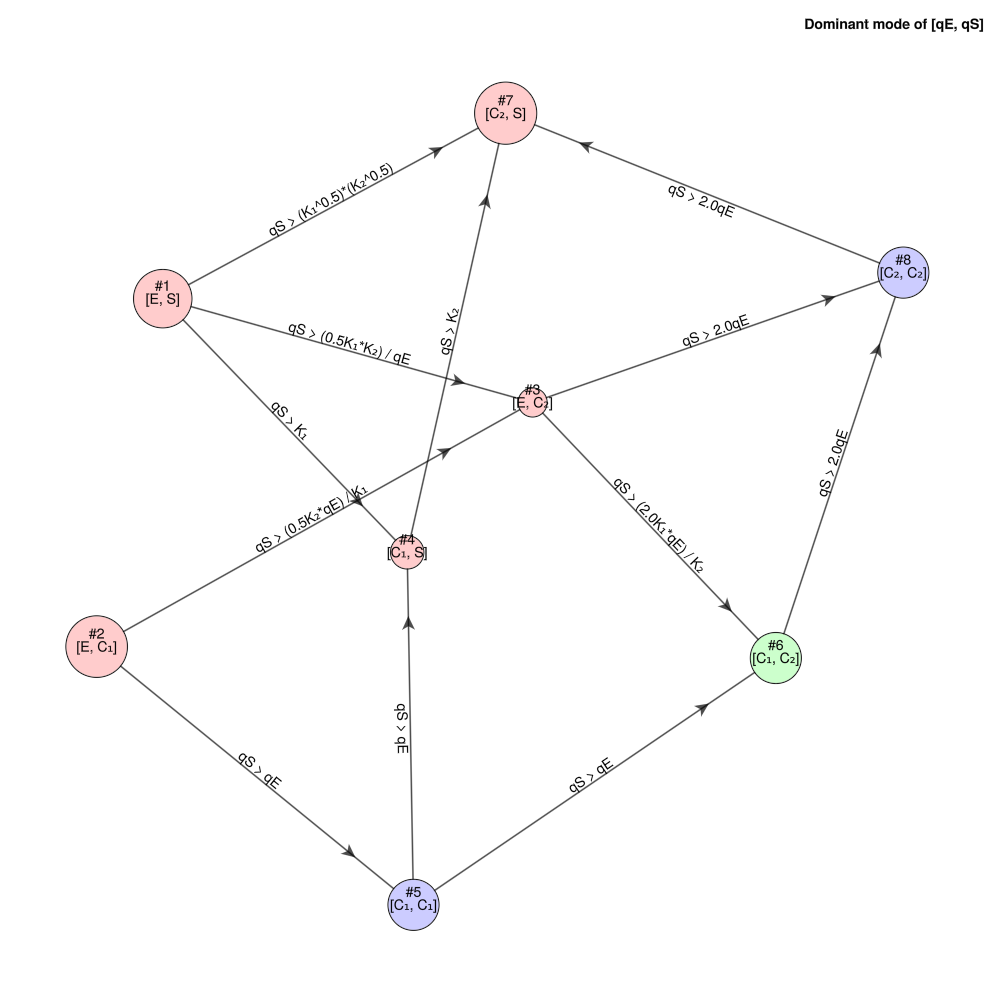

In [40]:
f,ax,p = draw_graph(pth1)
f

In [41]:
summary_RO_path(pth1, observe_x=:C₂)

[ Info: Start building polyhedra for edges (total: 12)
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
[ Info: Start building polyhedra for paths (total: 8) via suffix DAG with 16 unique suffix states across 5 layers
[ Info: Suffix DAG layer 1/5: 1 states
[ Info: Suffix DAG layer 2/5: 3 states
[ Info: Suffix DAG layer 3/5: 4 states
[ Info: Suffix DAG layer 4/5: 5 states
[ Info: Suffix DAG layer 5/5: 3 states
[ Info: Number of polyhedra to calc volume: 6
[ Info: All regimes converged after 1700000 samples.


Path [1, 2, 5, 6]  2 → 1 → NaN → 0        Volume: 0.2507 ± 0.0009
Path [4]           2 → 0                  Volume: 0.2501 ± 0.0012
Path [8]           2 → Inf → 1 → NaN → 0  Volume: 0.1670 ± 0.0008
Path [7]           2 → Inf → 1 → 0        Volume: 0.1665 ± 0.0008
Path [3]           2 → 1 → 0              Volume: 0.1660 ± 0.0008


In [43]:
show_expression_x(model1,2)

4-element Vector{Symbolics.Equation}:
 E ~ qE
 S ~ (K₁*qS) / qE
 C₁ ~ qS
 C₂ ~ (K₁*(qS^(2//1))) / (K₂*qE)

In [42]:
summary(pth1)

Path 1         #1 → #3 → #6 → #8 → #7  Volume: 0.0000 ± 0.0000
Path 2         #1 → #3 → #8 → #7       Volume: 0.0834 ± 0.0004
Path 3         #1 → #4 → #7            Volume: 0.1660 ± 0.0008
Path 4         #1 → #7                 Volume: 0.2501 ± 0.0012
Path 5         #2 → #3 → #6 → #8 → #7  Volume: 0.0000 ± 0.0000
Path 6         #2 → #3 → #8 → #7       Volume: 0.1673 ± 0.0008
Path 7         #2 → #5 → #4 → #7       Volume: 0.1665 ± 0.0008
Path 8         #2 → #5 → #6 → #8 → #7  Volume: 0.1670 ± 0.0008


In [ ]:
filter(model) = let
    rgms = get_regimes(model,singular=false)
    x_idx = locate_sym_x(model,:C₂)
    qE_idx = locate_sym_q(model,:qE)
    qS_idx = locate_sym_q(model,:qS)
    filter(rgms) do rgm
        H = get_H(rgm)
        H[x_idx, qE_idx] == 1 && H[x_idx, qS_idx] == 2
    end

In [239]:
show_expression_x(model1,5)

4-element Vector{Symbolics.Equation}:
 E ~ qE / qS
 S ~ qS / qE
 C₁ ~ 1
 C₂ ~ qS / qE

In [9]:
show_expression_path(pth1, 4; observe_x="C₂")

Expression path along regimes: 1 → 7
Regime 1
  C₂ ~ (qE*(qS^(2//1))) / (K₁*K₂)
  cross 1 → 7 when
    qS ~ (K₁^0.5)*(K₂^0.5)
Regime 7
  C₂ ~ qE


Using parameters: Dict(:K₂ => 0.0, :qE => -2.5121756136641498, :K₁ => 3.5777087639996634)


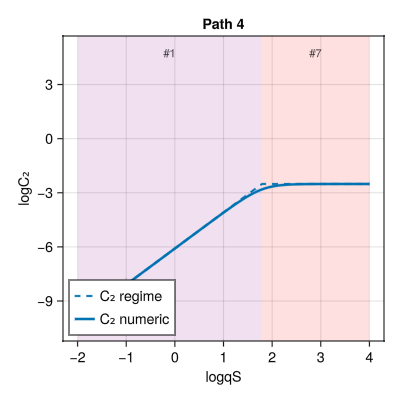

In [50]:
f,ax = SISO_plot(pth1,4; observe_x=:C₂, start=-2,stop=4,size = (400,400))
f

In [45]:
save("Hill_2_1.png", f,px_per_unit=4)

Model1 analysis

In [56]:
x_sym(model1)

4-element Vector{Symbolics.Num}:
  E
  S
 C₁
 C₂

In [111]:
qK_sym(model1)

4-element Vector{Symbolics.Num}:
 qE
 qS
 K₁
 K₂

In [44]:
diff_hill_exact(logx, logqK) = let
    qE = exp10(logqK[1])
    qS = exp10(logqK[2])
    K_1 = exp10(logqK[3])
    K_2 = exp10(logqK[4])
    C2_hill = log10(qE*qS^2/(K_1*K_2+ qS^2))
    C2 = logx[4]
    diff = C2_hill - C2
    diff = clamp(diff, -2, 2)
    diff
end

diff_rgm_exact(logx, logqK) = let
    logx_rgm = qK2x(model1, logqK;input_logspace=true, output_logspace=true,method=:regime)
    C2 = logx[4]
    diff = logx_rgm[4] - C2
    diff = clamp(diff, -2, 2)
    diff
end

my_cmap = begin
    neg = cgrad([:blue,:black], 100; rev=true).colors.colors
    mid = cgrad([:blue,"#D9D9D9",:red], 200).colors.colors
    pos = cgrad([:red,:black], 100).colors.colors
    vcat(neg, mid, pos)
end

fixed = Dict(:K₂ => -3, :K₁ => 3)
ranges = (-6,6)

(-6, 6)

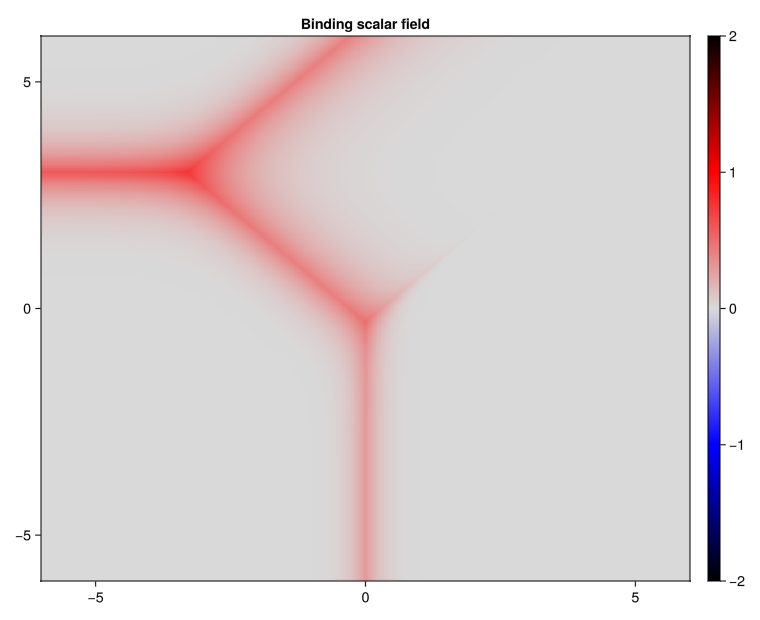

In [212]:
f,ax,data = plot_binding_regime_partition(model1; axes= [:qS, :qE],ranges, fixed, n=500, value_func=diff_rgm_exact, colormap=my_cmap, colorrange=(-2,2),method=:homotopy)
f

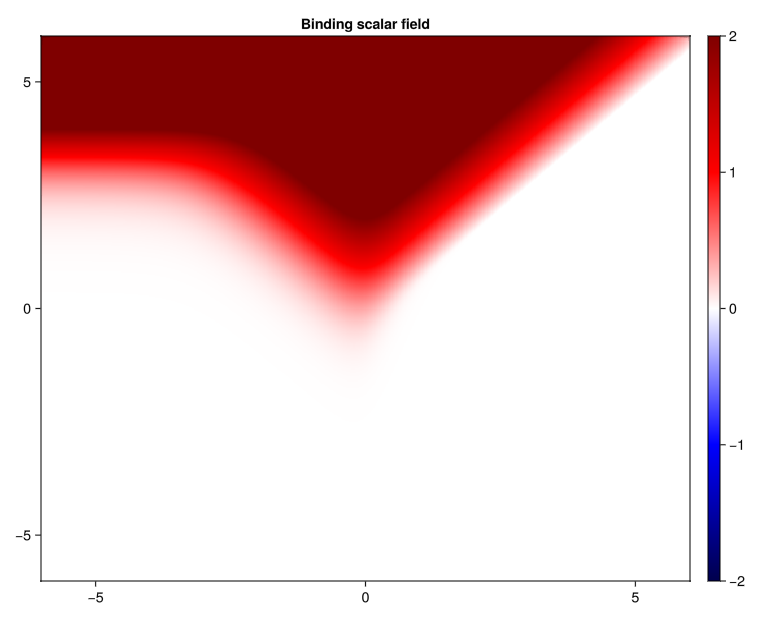

In [46]:
my_cmap = :seismic
f,ax,data = plot_binding_regime_partition(model1; axes= [:qS, :qE],ranges, fixed, n=500, value_func=diff_hill_exact, colormap=my_cmap, colorrange=(-2,2))
f

In [47]:
rgms = plot_binding_regime_partition(model1; axes= [:qS, :qE], fixed,ranges, n=500)[3][3]
bnds = find_bounds(rgms)
contour!(ax, data[2][1], data[2][2],  bnds, color = :gray, linestyle=:dash)

Contour{Tuple{StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}, StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}, Matrix{Float32}}}

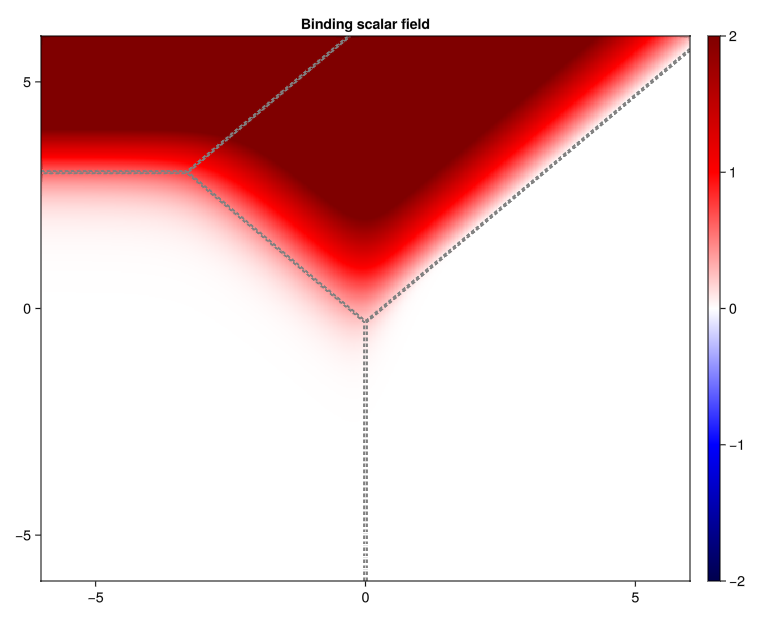

In [48]:
f

In [49]:
save("Hill_2_1_heatmap_rgm.png", f, px_per_unit=3)

In [206]:
show_expression_x(model1,2)

4-element Vector{Symbolics.Equation}:
 E ~ qE
 S ~ (K₁*qS) / qE
 C₁ ~ qS
 C₂ ~ (K₁*(qS^(2//1))) / (K₂*qE)

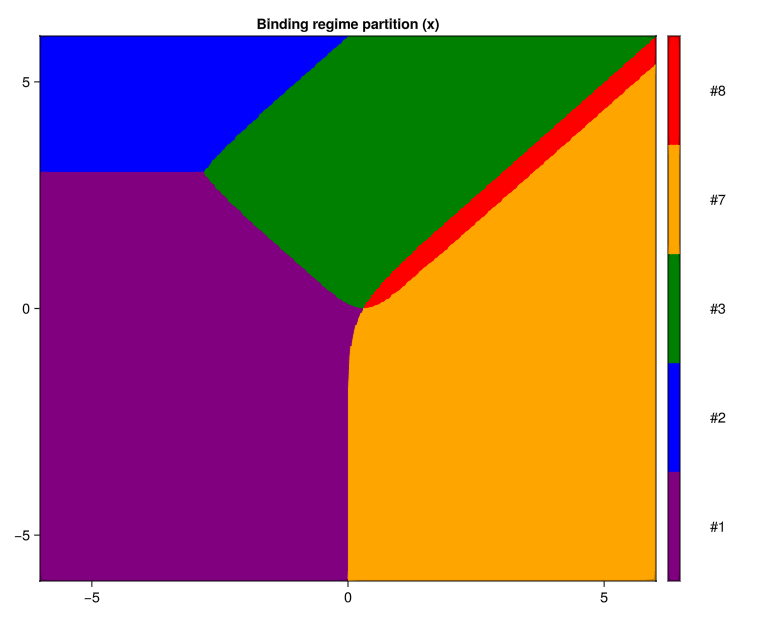

In [224]:
plot_binding_regime_partition(model1; axes= [:qS, :qE],ranges, fixed, n=500,chart=:x)[1]

Using parameters: Dict(:K₂ => 0.0, :qE => 4.466766508914031, :K₁ => 6.406135888745853)


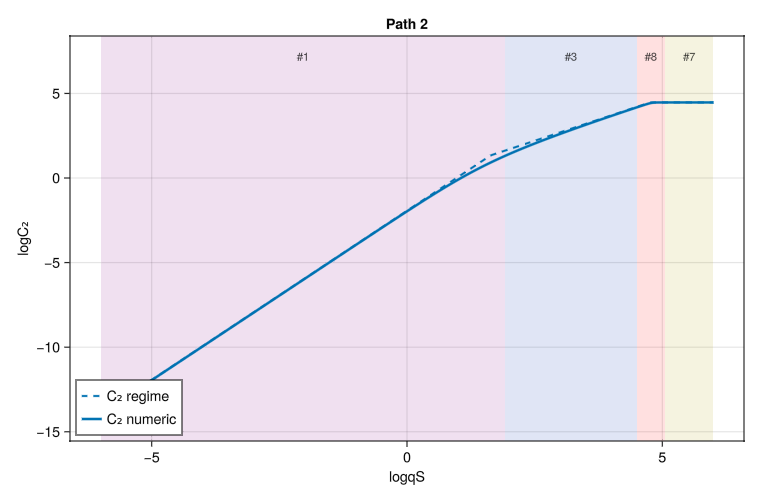

In [131]:
f,ax = SIMO_plot(pth1,2, observe_x=[:C₂]);f

In [128]:
summary(pth1)

Path 1         #1 → #3 → #6 → #8 → #7  Volume: 0.0000 ± 0.0000
Path 2         #1 → #3 → #8 → #7       Volume: 0.0833 ± 0.0004
Path 3         #1 → #4 → #7            Volume: 0.1656 ± 0.0008
Path 4         #1 → #7                 Volume: 0.2501 ± 0.0012
Path 5         #2 → #3 → #6 → #8 → #7  Volume: 0.0000 ± 0.0000
Path 6         #2 → #3 → #8 → #7       Volume: 0.1675 ± 0.0008
Path 7         #2 → #5 → #4 → #7       Volume: 0.1665 ± 0.0008
Path 8         #2 → #5 → #6 → #8 → #7  Volume: 0.1670 ± 0.0008


Model2 analysis

In [56]:
pth2 = SIMOPaths(model2,:qS)

[ Info: sources: [1]
[ Info: sinks: [4]
[ Info: Start enumerating paths from sources to sinks. This may take a while if there are many paths.
[ Info: Total vertices to process in topological order: 6
[ Info: Finished enumerating paths. Now collecting paths from sources. Total sources: 1


SIMOPaths object with 4 paths for qK coordinate index 2

[ Info: All regimes converged after 3000000 samples.


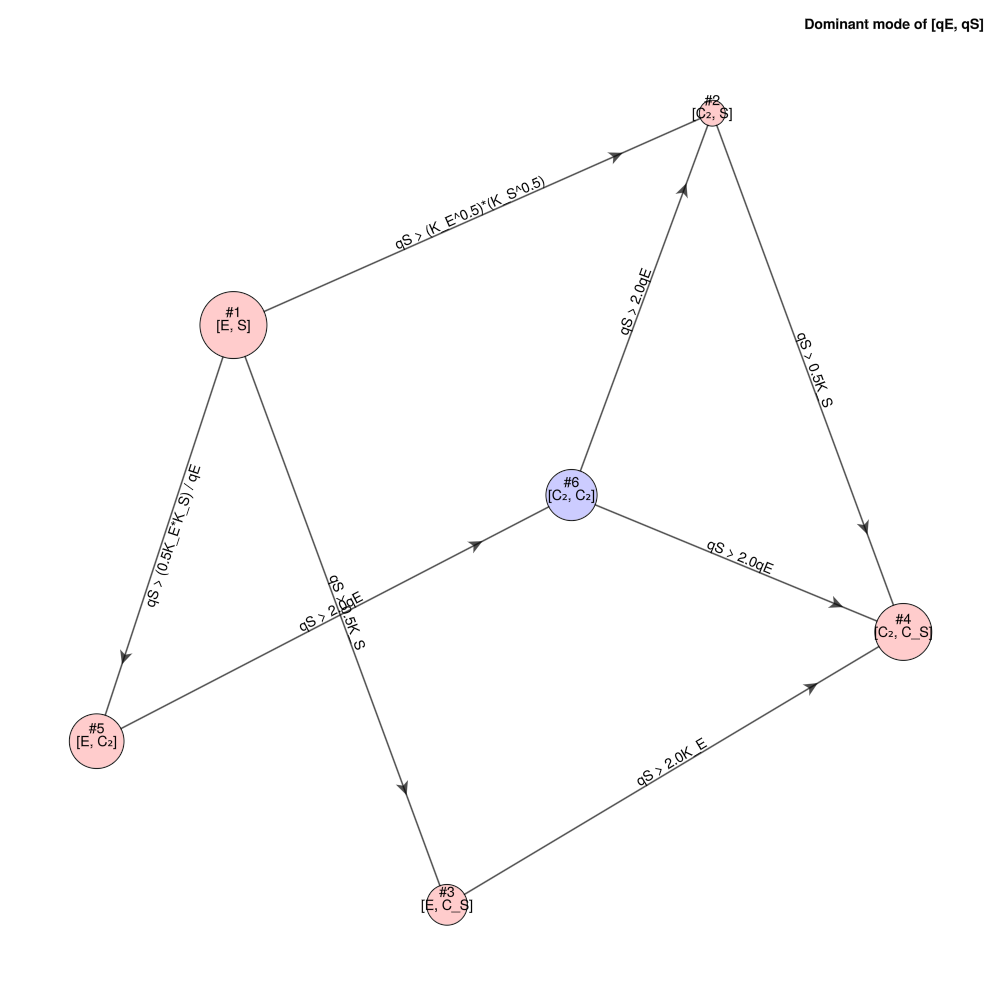

In [57]:
f,ax, p = draw_graph(pth2)
f

In [58]:
summary(pth2)

[ Info: Start building polyhedra for edges (total: 8)
[ Info: Start building polyhedra for paths (total: 4) via suffix DAG with 11 unique suffix states across 5 layers
[ Info: Suffix DAG layer 1/5: 1 states
[ Info: Suffix DAG layer 2/5: 3 states
[ Info: Suffix DAG layer 3/5: 4 states
[ Info: Suffix DAG layer 4/5: 2 states
[ Info: Suffix DAG layer 5/5: 1 states
[ Info: Number of polyhedra to calc volume: 4


Path 1         #1 → #2 → #4            Volume: 0.2499 ± 0.0012
Path 2         #1 → #3 → #4            Volume: 0.3325 ± 0.0015
Path 3         #1 → #5 → #6 → #2 → #4  Volume: 0.0833 ± 0.0004
Path 4         #1 → #5 → #6 → #4       Volume: 0.3343 ± 0.0015


[ Info: All regimes converged after 1700000 samples.


In [59]:
summary_RO_path(pth2, observe_x=:C₂)

Path [3, 4]    2 → 1 → NaN → 0  Volume: 0.4176 ± 0.0015
Path [2]       2 → 1 → 0        Volume: 0.3325 ± 0.0015
Path [1]       2 → 0            Volume: 0.2499 ± 0.0012


In [69]:
show_expression_x(model2,1)

4-element Vector{Symbolics.Equation}:
 E ~ qE
 S ~ qS
 C_S ~ (qS^(2//1)) / K_S
 C₂ ~ (qE*(qS^(2//1))) / (K_E*K_S)

Using parameters: Dict(:qE => -2.2111456180001685, :K_S => 4.1797687553276255, :K_E => 0.0)


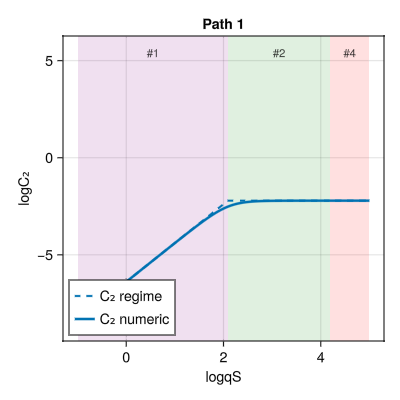

In [49]:
f,ax = SISO_plot(pth2,1; observe_x=:C₂, start=-1,stop=5,size = (400,400))
f

In [47]:
save("Hill_2_2.png", f,px_per_unit=4)

In [ ]:
x_sym(model2)

4-element Vector{Symbolics.Num}:
   E
   S
 C_S
  C₂

In [ ]:
qK_sym(model2)

4-element Vector{Symbolics.Num}:
  qE
  qS
 K_S
 K_E

In [50]:
diff_hill_exact(logx, logqK) = let
    qE = exp10(logqK[1])
    qS = exp10(logqK[2])
    K_S = exp10(logqK[3])
    K_E = exp10(logqK[4])
    C2_hill = log10(qE*qS^2/(K_S*K_E+ qS^2))
    C2 = logx[4]
    diff = C2_hill - C2
    diff = clamp(diff, -2, 2)
    diff
end
diff_rgm_exact(logx, logqK) = let
    logx_rgm = qK2x(model2, logqK;input_logspace=true, output_logspace=true,method=:regime)
    C2 = logx[4]
    diff = logx_rgm[4] - C2
    diff = clamp(diff, -2, 2)
    diff
end
fixed = Dict(:K_S => 3, :K_E => -3)
ranges = (-6,6)

(-6, 6)

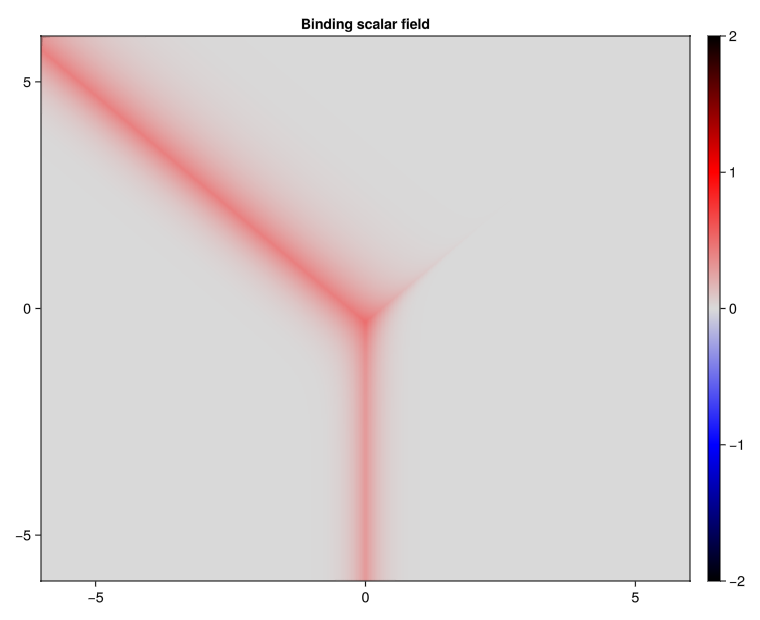

In [218]:
f,ax,data = plot_binding_regime_partition(model2; axes= [:qS, :qE],ranges, fixed, n=500, value_func=diff_rgm_exact, colormap=my_cmap, colorrange=(-2,2))
f

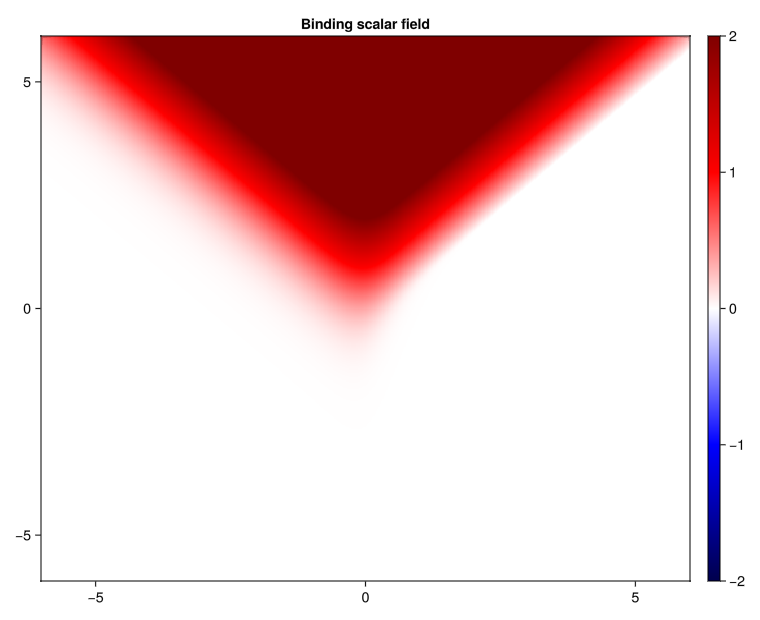

In [51]:
f,ax,data = plot_binding_regime_partition(model2; axes= [:qS, :qE],ranges, fixed, n=500, value_func=diff_hill_exact, colormap=my_cmap, colorrange=(-2,2))
f

In [52]:
rgms = plot_binding_regime_partition(model2; axes= [:qS, :qE], fixed,ranges, n=500)[3][3]
bnds = find_bounds(rgms)
contour!(ax, data[2][1], data[2][2],  bnds, color = :gray, linestyle=:dash)

Contour{Tuple{StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}, StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}, Matrix{Float32}}}

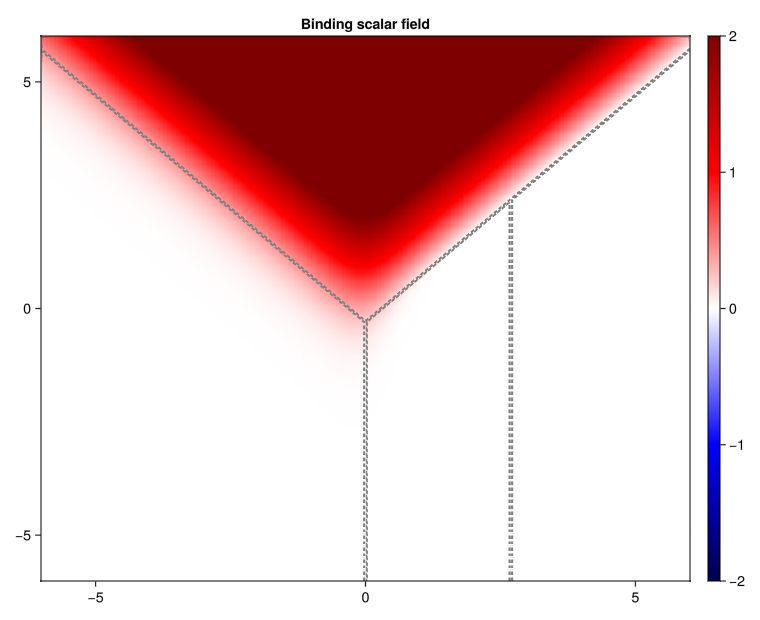

In [53]:
f

In [55]:
show_conservation(model1)

2-element Vector{Symbolics.Equation}:
 qE ~ C₁ + C₂ + E
 qS ~ C₁ + 2C₂ + S

In [54]:
save("Hill_2_2_heatmap_rgm.png", f, px_per_unit=3)

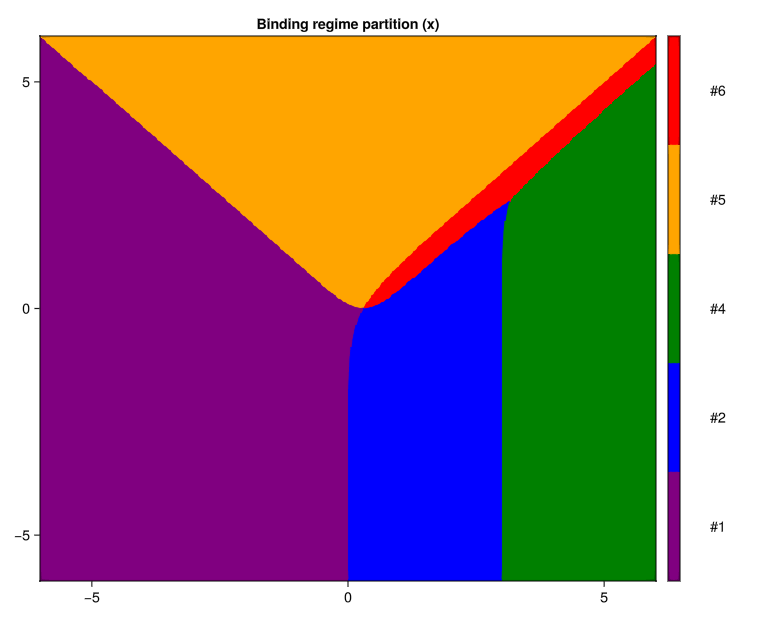

In [229]:
plot_binding_regime_partition(model2; axes= [:qS, :qE],ranges, fixed, n=500,chart=:x)[1]

In [102]:
summary_path(grh2, :C₂;deduplicate=true, keep_singular=false, keep_nonasymptotic=false)  |> render_path

[ Info: Number of polyhedra to calc volume: 4


Path [2, 3, 4]        2 → 1 → 0                     	  Volume: 0.7486 ± 0.0033
Path [1]              2 → 0                         	  Volume: 0.251  ± 0.0012


[ Info: All regimes converged after 1700000 samples.
[ Info: Total samples: 1700000, Elapsed: 0.31 s


In [103]:
summary_path(grh1, :C₂;deduplicate=true, keep_singular=false, keep_nonasymptotic=false)  |> render_path

[ Info: Number of polyhedra to calc volume: 6


Path [1, 2, 3, 5, 6, 7]  2 → 1 → 0                     	  Volume: 0.5826 ± 0.0029
Path [4, 8]           2 → 0                         	  Volume: 0.4172 ± 0.002 


[ Info: All regimes converged after 1700000 samples.
[ Info: Total samples: 1700000, Elapsed: 0.18 s


In [73]:
show_condition(pth2,1)

2-element Vector{Symbolics.Num}:
 (0.25K_E*K_S) > (qE^2.0)
          (0.25K_S) > K_E

In [56]:
q_sym = [:tE, :tS]
K_sym = [:K₁, :K₂,:K₃]
# K_sym2 = [:K_S, :K_E]
x_sym = [:E, :S, :C₁, :C₂, :C₃]
# x_sym2 = [:E, :S, :C_S, :C₂]
N1 =     [0  2  -1  0  0;
           1  1  0  -1  0
          1  0  1   0  -1]

N2 =     [0  2  -1  0  0;
           1  1  0  -1  0
          0  1  0   1  -1]

model1 = Bnc(N=N1, x_sym=x_sym, q_sym=q_sym, K_sym=K_sym)
model2 = Bnc(N=N2, x_sym=x_sym, q_sym=q_sym, K_sym=K_sym)

find_all_vertices!(model1)
find_all_vertices!(model2)
summary(model1)
summary(model2)

---------------------Start finding all vertices, it may takes a while.--------------------
Finished, with 11 vertices found and 10 asymptotic vertices.

-------------Start calculating nullity for each vertex, it also takes a while.------------
1.Building Nρ_inv cache in parallel...
2.Calculating nullity for each vertex in parallel...
3.Storing all vertices information...
Done.
---------------------Start finding all vertices, it may takes a while.--------------------
Finished, with 11 vertices found and 10 asymptotic vertices.

-------------Start calculating nullity for each vertex, it also takes a while.------------
1.Building Nρ_inv cache in parallel...
2.Calculating nullity for each vertex in parallel...
3.Storing all vertices information...
Done.
----------Binding Network Summary:-------------
Number of species (n): 5
Number of conserved quantities (d): 2
Number of reactions (r): 3
L matrix: [1 0 0 1 1; 0 1 2 1 2]
N matrix: [0 2 -1 0 0; 1 1 0 -1 0; 1 0 1 0 -1]
Direction of binding r

----------------Start calculating vertices neighbor graph, It may takes a while.----------------
Done.

-------Start calculating vertices neighbor graph with qK change dir, It may takes a while.------------
Done.



[ Info: Number of polyhedra to calc volume: 8
[ Info: All regimes converged after 4800000 samples.
[ Info: Total samples: 4800000, Elapsed: 0.99 s


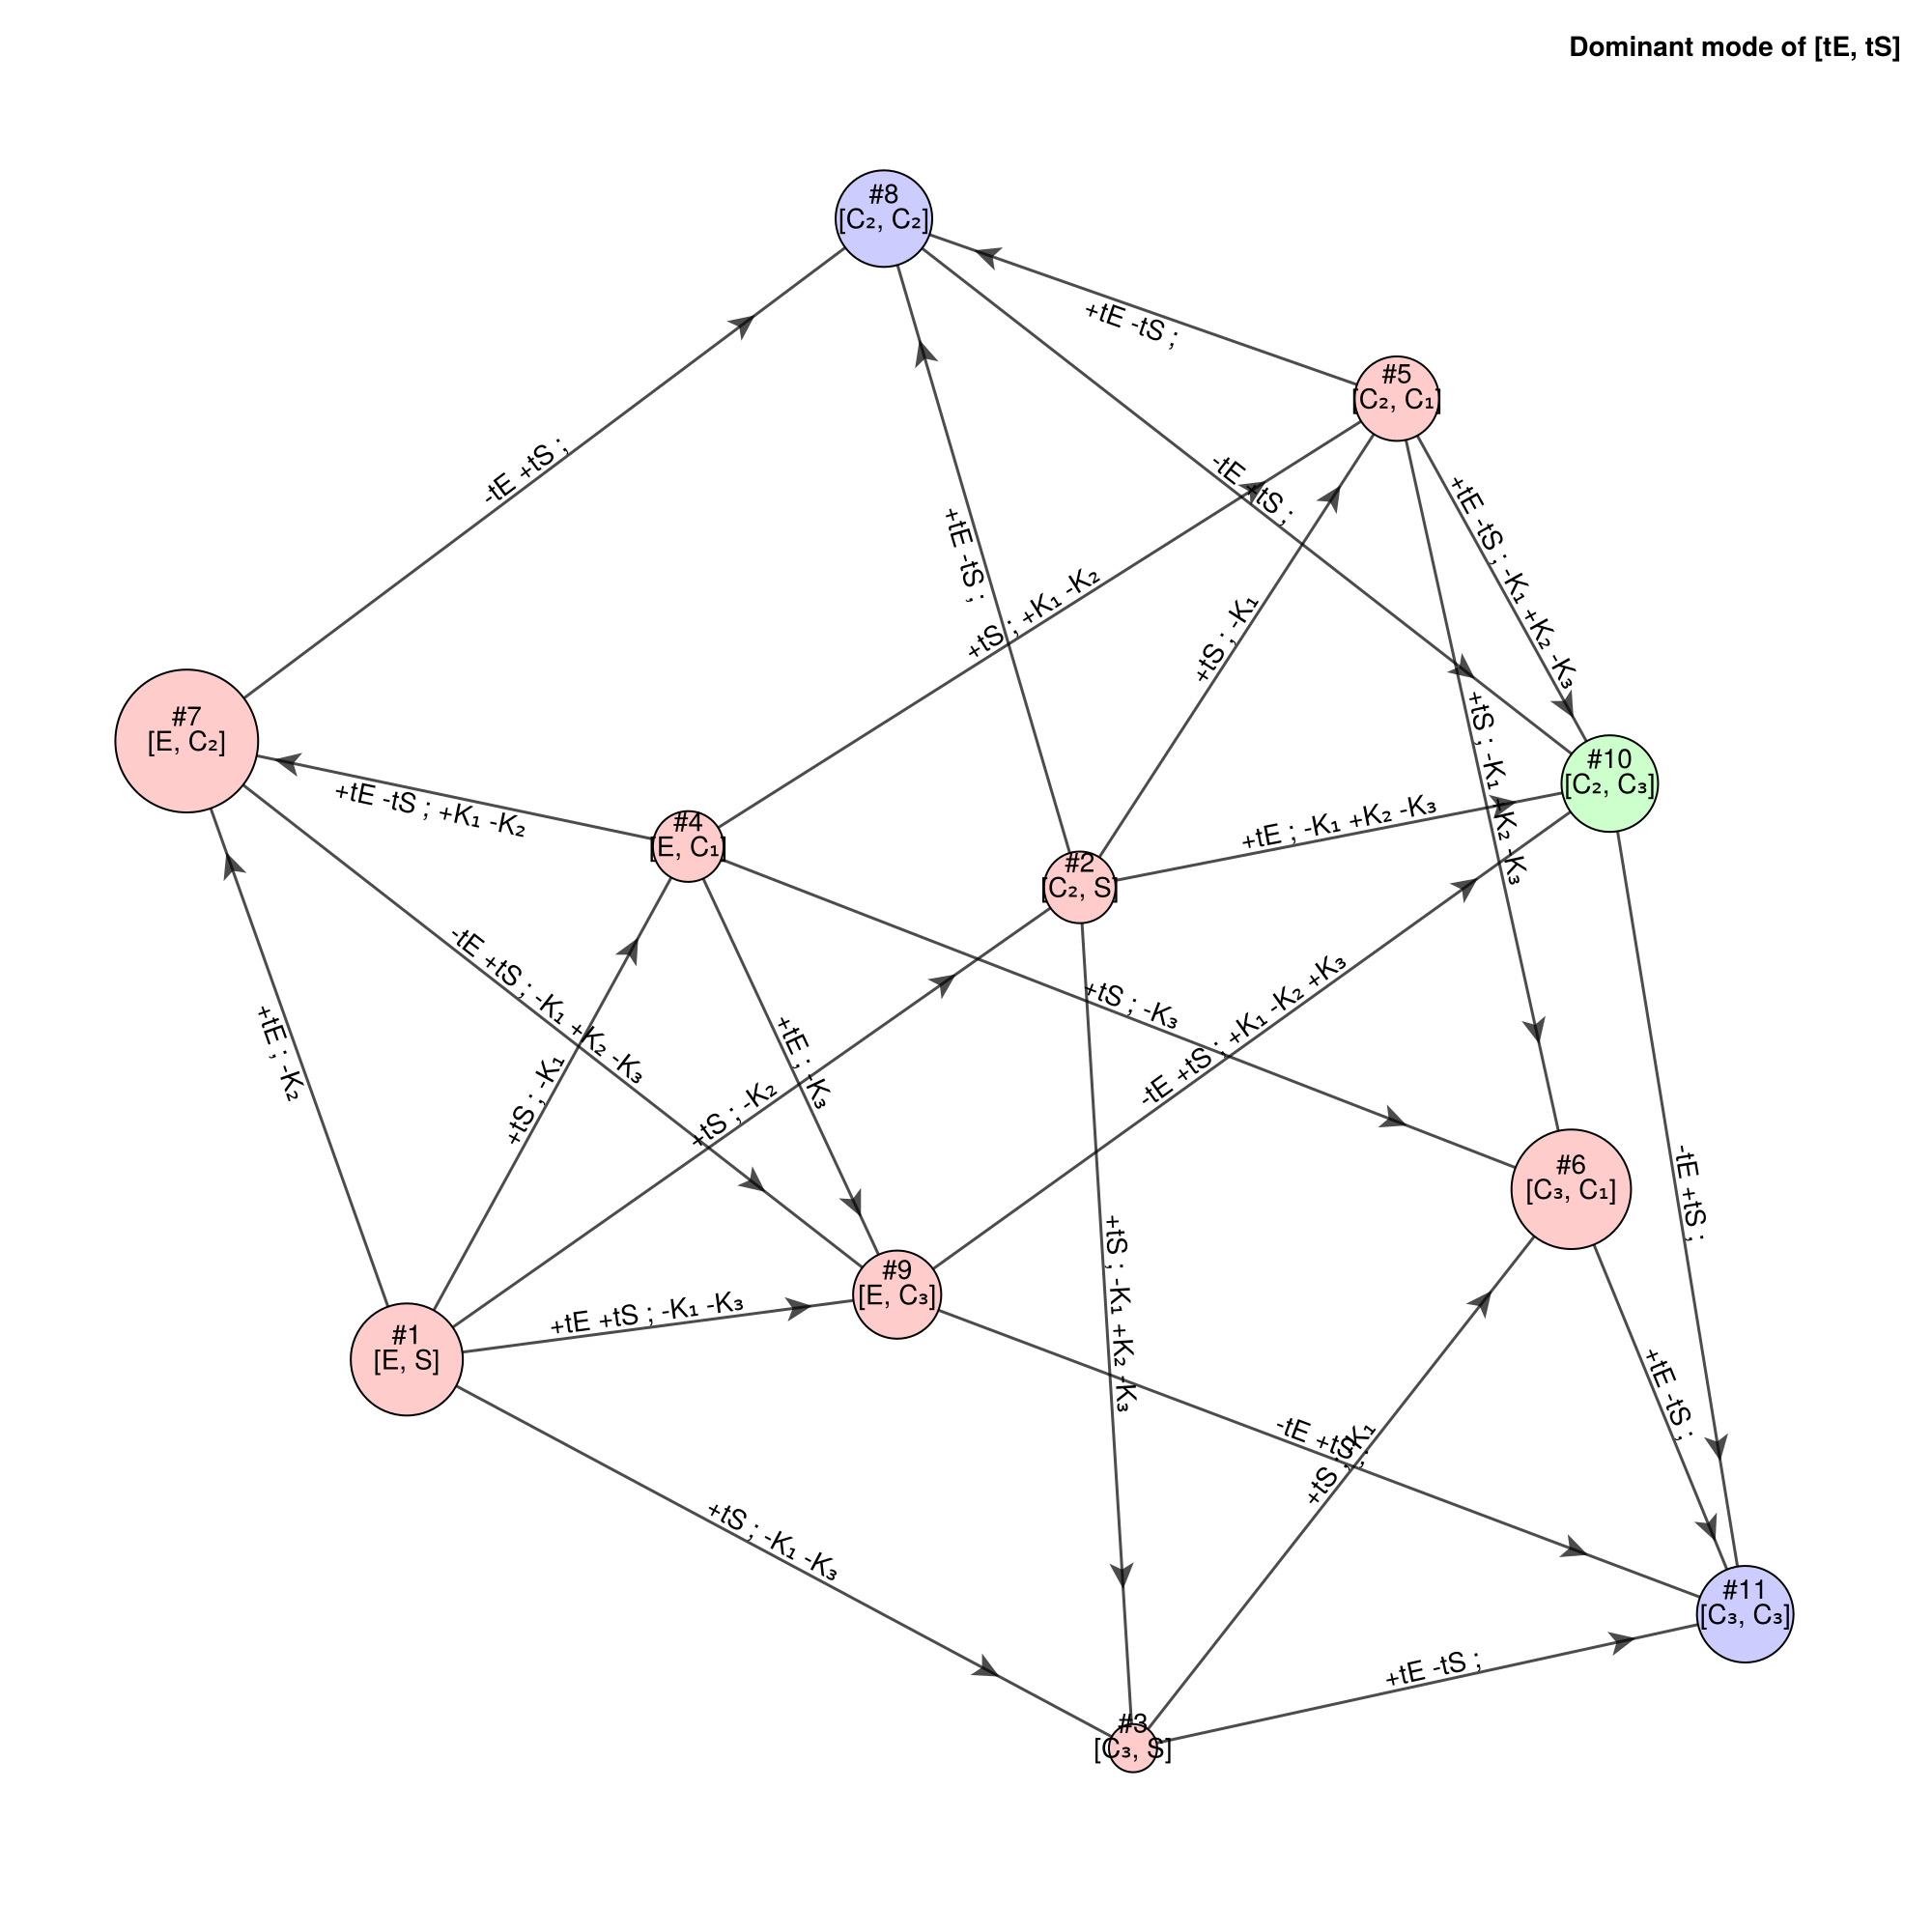

CairoMakie.Screen{IMAGE}


In [57]:
f,ax,p = draw_vertices_neighbor_graph(model1)
add_vertices_idx!(ax,p)
display(f)

----------------Start calculating vertices neighbor graph, It may takes a while.----------------
Done.

-------Start calculating vertices neighbor graph with qK change dir, It may takes a while.------------
Done.



[ Info: Number of polyhedra to calc volume: 8


[ Info: All regimes converged after 4500000 samples.
[ Info: Total samples: 4500000, Elapsed: 0.76 s


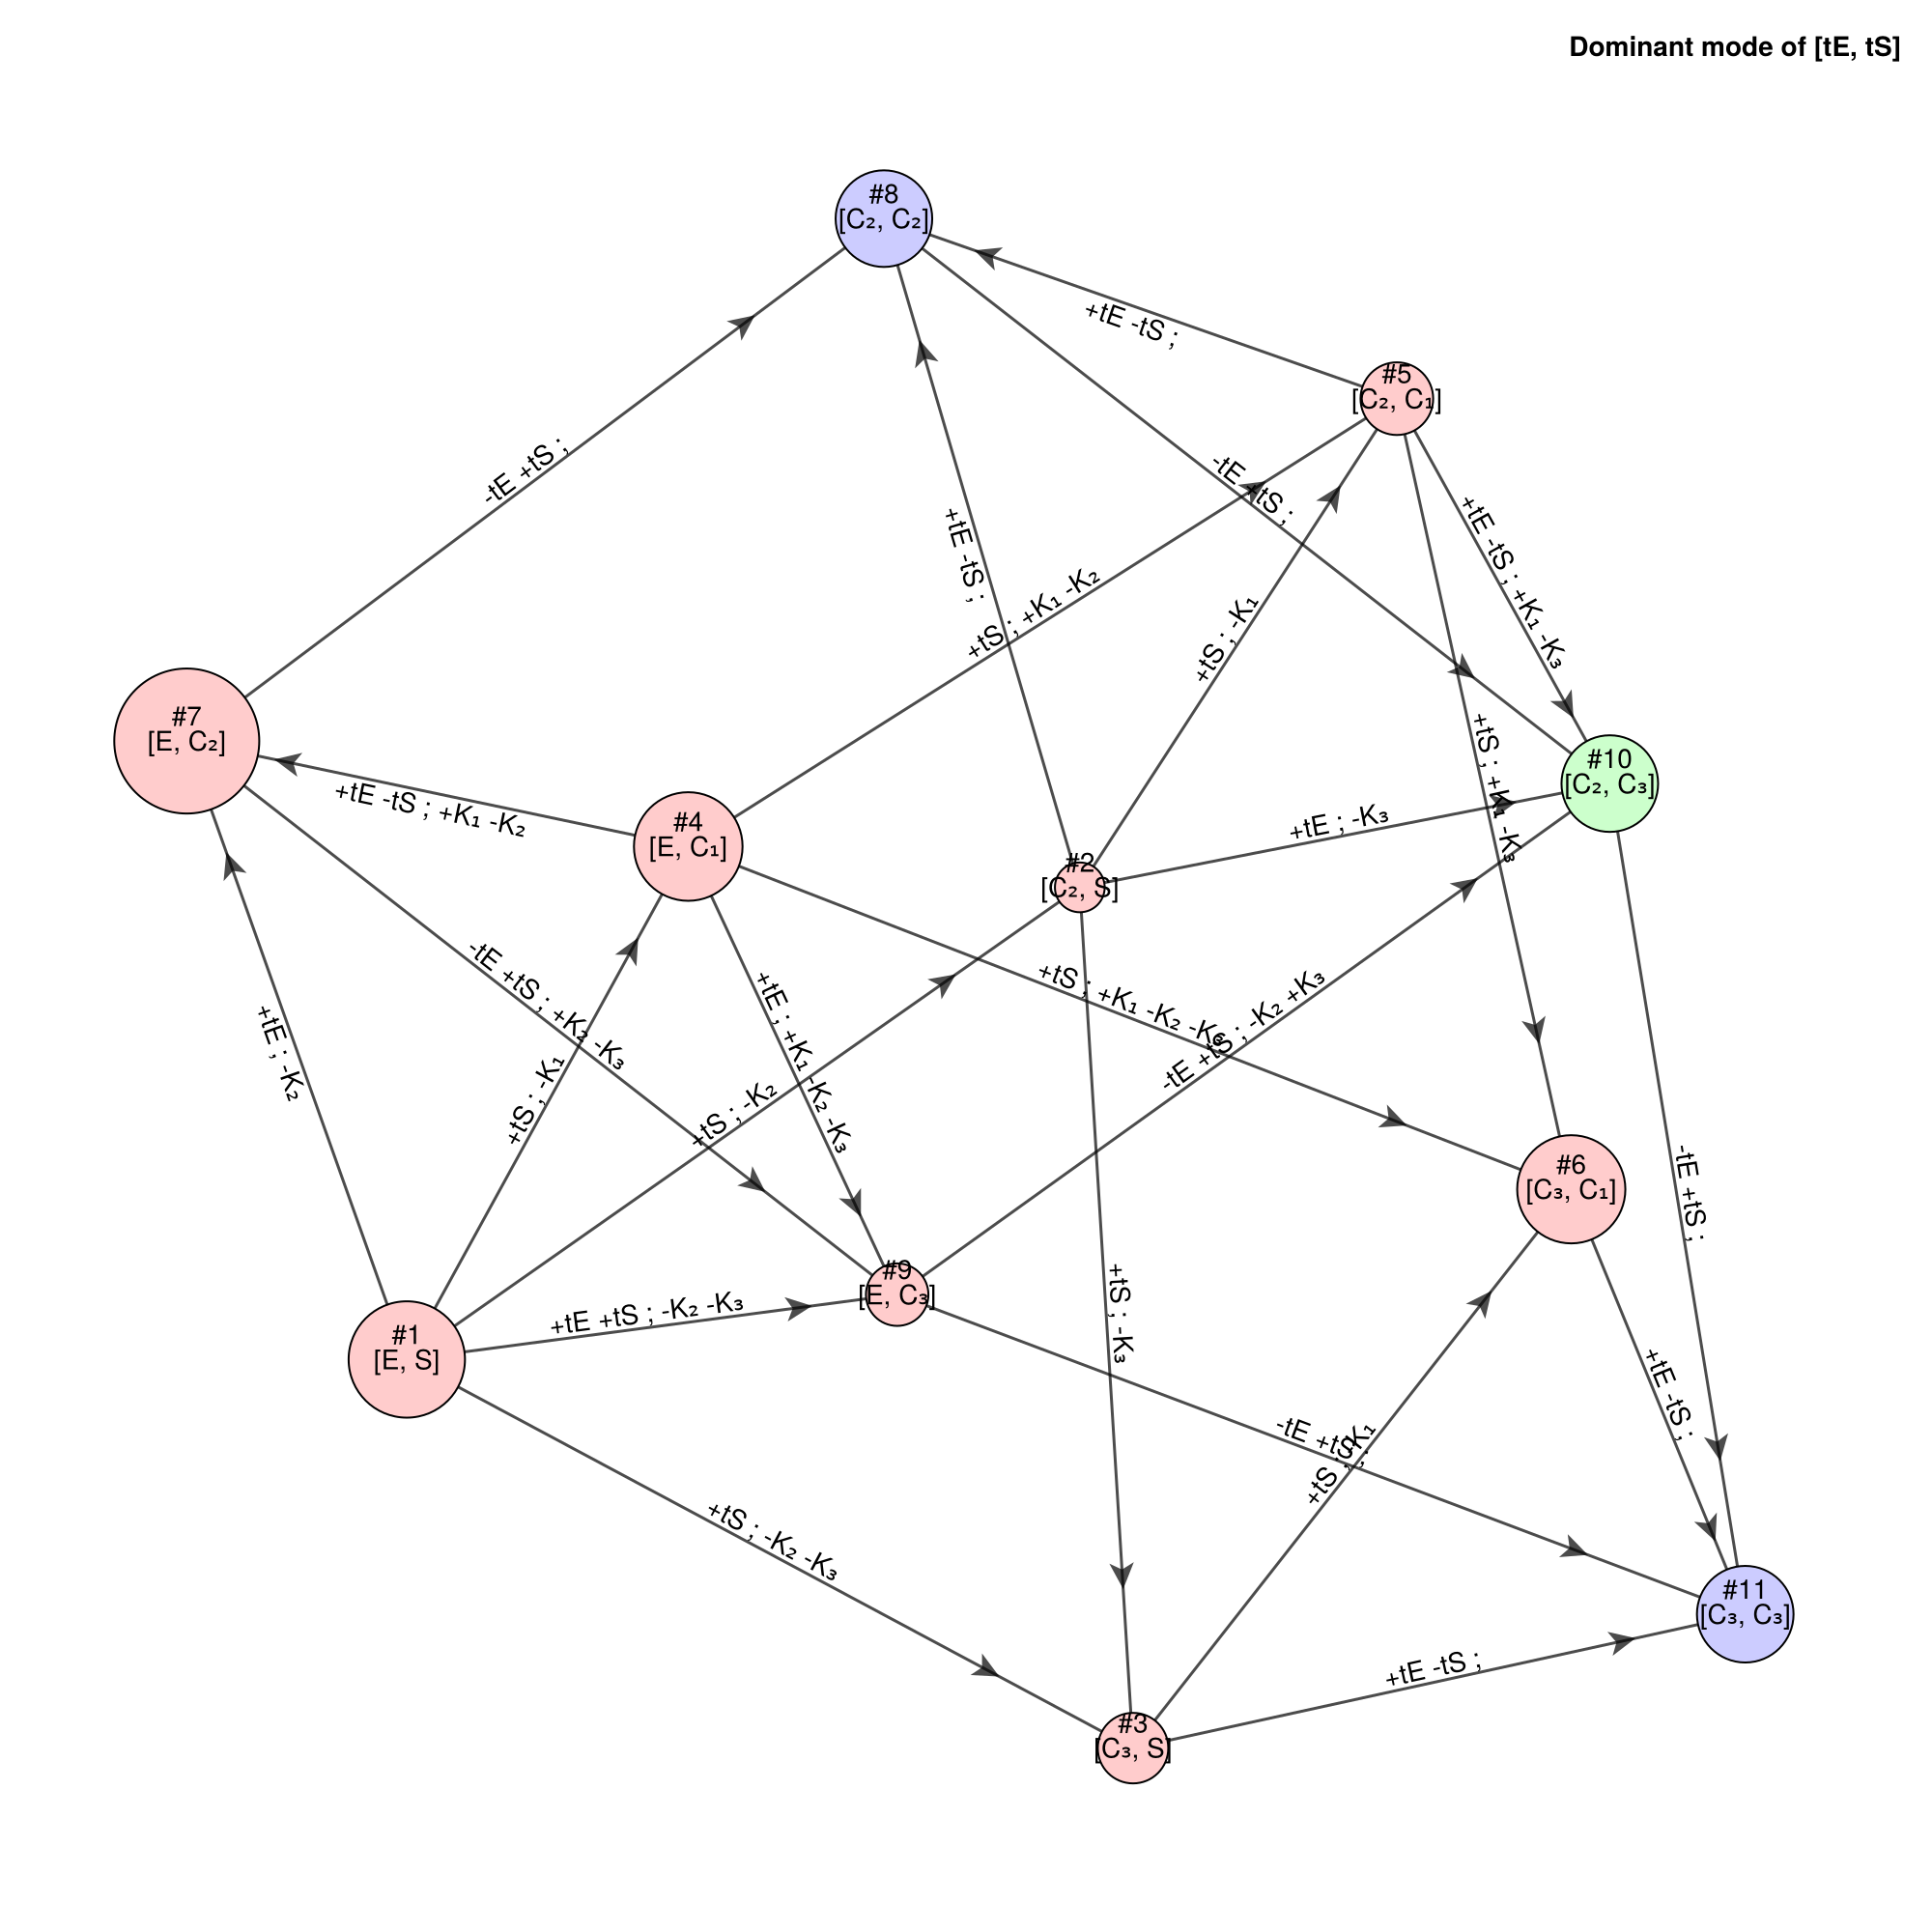

CairoMakie.Screen{IMAGE}


In [58]:
f,ax,p = draw_vertices_neighbor_graph(model2)
add_vertices_idx!(ax,p)
display(f)

In [59]:
grh1 = SISO_graph(model1, :tS)
grh2 = SISO_graph(model2, :tS)

[ Info: sources: [7, 1]
[ Info: sinks: [6]
[ Info: sources: [7, 1]
[ Info: sinks: [6]


SISO_graph{Int8}(Bnc{Int8}([0 2 … 0 0; 1 1 … -1 0; 0 1 … 1 -1], [1 0 … 1 1; 0 1 … 1 2], 3, 5, 2, Num[E, S, C₁, C₂, C₃], Num[tE, tS], Num[K₁, K₂, K₃], nothing, Vector{Int8}[[1, 2], [4, 2], [5, 2], [1, 3], [4, 3], [5, 3], [1, 4], [4, 4], [1, 5], [4, 5], [5, 5]], Dict{Vector{Int8}, Int64}([5, 5] => 11, [4, 2] => 2, [1, 4] => 7, [1, 2] => 1, [4, 3] => 5, [4, 5] => 10, [1, 3] => 4, [5, 2] => 3, [1, 5] => 9, [5, 3] => 6…), Bool[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1], Int8[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1], VertexGraph{Int8}(SimpleGraph{Int64}(25, [[2, 3, 4, 7, 9], [1, 3, 5, 8, 10], [1, 2, 6, 11], [1, 5, 6, 7, 9], [2, 4, 6, 8, 10], [3, 4, 5, 11], [1, 4, 8, 9], [2, 5, 7, 10], [1, 4, 7, 10, 11], [2, 5, 8, 9, 11], [3, 6, 9, 10]]), Vector{VertexEdge{Int8}}[[VertexEdge{Int8}(2, 1, sparsevec(Int8[1, 4], Int8[-1, 1], 5), sparsevec(Int8[2, 4], [1.0, -1.0], 5)), VertexEdge{Int8}(3, 1, sparsevec(Int8[1, 5], Int8[-1, 1], 5), sparsevec(Int8[2, 4, 5], [2.0, -1.0, -1.0], 5)), VertexEdge{Int8}(4, 2, sparsevec(Int8

In [64]:
summary_path(grh1, :C₃; deduplicate=true,keep_singular=false,keep_nonasymptotic=false) |> render_path

Path[1, 5, 7, 8, 9, 10, 12, 13, 20, 21, 22, 23]:  2 → 1 → 0	 | Volume: 0.4479 ± 0.0022
Path[2, 4, 6, 11, 14, 19]:  2 → 1 → 0.5 → 0	 | Volume: 0.2498 ± 0.0012
Path[3, 17, 18]:  2 → 0	 | Volume: 0.1668 ± 0.0008
Path[15, 16]:  2 → 0.5 → 0	 | Volume: 0.1351 ± 0.0007


In [66]:
summary_path(grh2, :C₃; deduplicate=true,keep_singular=true,keep_nonasymptotic=true) |> render_path

Path[1, 5, 7, 8, 9, 10, 12, 20, 21, 22, 23]:  2 → 1 → 0	 | Volume: 0.4378 ± 0.0021
Path[2, 4, 6, 11, 19]:  2 → 1 → 0.5 → 0	 | Volume: 0.1564 ± 0.0008
Path[13, 17, 18]:  2 → Inf → 1 → 0	 | Volume: 0.1563 ± 0.0008
Path[15]:  2 → Inf → 0.5 → 0	 | Volume: 0.1042 ± 0.0005
Path[3]:  2 → 0	 | Volume: 0.104 ± 0.0005
Path[14, 16]:  2 → Inf → 1 → 0.5 → 0	 | Volume: 0.0416 ± 0.0002


In [224]:
a, b = get_expression_for_path(grh1, 3, :C₃; log_space=false)
a .|> display
println("----------")
b .|> display

grh1.rgm_volume[3]

(tE*(tS^2.0)) / (K₁*K₃)

tE

tE

----------


(K₁^0.5)*(K₃^0.5)

0.5K₁

0.10400751513487422

In [229]:
grh1.rgm_volume .- grh2.rgm_volume

23-element Vector{Float64}:
 -0.010305322358246778
  0.04192218366574525
 -0.000395713199917172
 -0.052049144767082035
 -0.041925149080153074
  0.0
  0.0
  0.0
  5.8124953482369124e-5
  0.06211948150516383
 -0.020893623035980434
 -0.010336504836587117
 -0.020880164553209506
  0.08315157876737841
  0.03187845502666872
  0.0
 -0.03129523070337783
 -0.020653206069935245
  0.0
  0.0
  0.0
 -0.031248371361147116
  0.021761519148947167

In [227]:
grh2.rgm_volume

23-element Vector{Float64}:
 0.04165298908921334
 0.04186993330216271
 0.10440322833479139
 0.08339035316988389
 0.17706655066943428
 0.0
 0.0
 0.0
 0.03116683354235474
 0.020853813783608687
 0.03125245847382877
 0.020738197406093013
 0.04175521120235721
 0.0416488224269928
 0.10400394371610241
 0.0
 0.04170910014044992
 0.07286132041782416
 0.0
 0.0
 0.0
 0.04163965577010761
 0.10386251553273851

In [225]:
a, b = get_expression_for_path(grh2, 3, :C₃; log_space=false)
a .|> display
println("----------")
b .|> display

grh2.rgm_volume[3]

(tE*(tS^2.0)) / (K₂*K₃)

tE

tE

----------


(K₂^0.5)*(K₃^0.5)

0.5K₁

0.10440322833479139

In [221]:
find_reaction_order_for_path(grh2,:C₃;keep_singular=true,keep_nonasymptotic=true)

23-element Vector{Vector{<:Real}}:
 [2.0, 1.0, 0.0, 0.0]
 [2.0, 1.0, 0.5, 0.0]
 [2.0, 0.0, 0.0]
 [2.0, 1.0, 0.5, 0.0]
 [2.0, 1.0, 0.0]
 [2.0, 1.0, 1.0, 0.5, 0.0]
 [2.0, 1.0, 1.0, 0.0, 0.0, 0.0]
 [2.0, 1.0, 1.0, 0.0, 0.0]
 [2.0, 1.0, 0.0, 0.0, 0.0]
 [2.0, 1.0, 0.0, 0.0]
 [2.0, 1.0, 0.5, 0.0]
 [2.0, 1.0, 0.0]
 [2.0, Inf, 1.0, 0.0, 0.0]
 [2.0, Inf, 1.0, 0.5, 0.0]
 [2.0, Inf, 0.5, 0.0]
 [2.0, Inf, 1.0, 0.5, 0.0]
 [2.0, Inf, 1.0, 0.0, 0.0, 0.0]
 [2.0, Inf, 1.0, 0.0, 0.0]
 [2.0, 1.0, 1.0, 0.5, 0.0]
 [2.0, 1.0, 1.0, 0.0, 0.0, 0.0]
 [2.0, 1.0, 1.0, 0.0, 0.0]
 [2.0, 1.0, 0.0, 0.0, 0.0]
 [2.0, 1.0, 0.0, 0.0]

In [134]:
x_syms[3]

C1

In [26]:
function hill(n)
    function hill_N(hill_n)
        N = zeros(Int, hill_n,hill_n+2)
        N[:,1] .= 1
        for i in 1:hill_n
            N[i,i+1] = 1
            N[i,i+2] = -1
        end
        return N
    end

    N = hill_N(n)
    x_syms = Num.(vcat([:S, :E], name_converter("C".*repr.(1:n))))
    q_syms = [:tS, :tE]
    K_syms = Num.(name_converter("K".* repr.(1:n)))
    model = Bnc(N=N, x_sym=x_syms, q_sym=q_syms, K_sym=K_syms)
    perm1 = [1,2]
    perm2 = [1,n+2]

    P1,P01 = _calc_P_and_P0(model, perm1)
    P2,P02 = _calc_P_and_P0(model, perm2)

    Cx1, C0x1 = _calc_C_C0_x(model, perm1)
    Cx2, C0x2 = _calc_C_C0_x(model, perm2)

    M1 = vcat(P1, N)
    M10 = vcat(P01, zeros(size(N,1)))
    M2 = vcat(P2, N)
    M20 = vcat(P02, zeros(size(N,1)))

    H1 = inv(Array(M1))
    H10 = -H1 * M10
    H2 = inv(Array(M2))
    H20 = -H2 * M20

    Cqk1 = Cx1 * H1
    C0qk1 = Cx1 * H10 + C0x1
    Cqk2 = Cx2 * H2
    C0qk2 = Cx2 * H20 + C0x2

    p = intersect(get_polyhedra(Cqk1,C0qk1), get_polyhedra(Cqk2,C0qk2))
    
    println("time to eliminate variables: ")
    p = eliminate(p, BitSet(1))
    detecthlinearity!(p)
    removevredundancy!(p)

    # obs_x = n+2

    # grh = SISO_graph(model, :tS)
    # pths = find_reaction_order_for_path(grh, obs_x; deduplicate=true, keep_singular=true, keep_nonasymptotic=true)
    # vals = ones(Float64, length(pths))
    # @show pths
    # pth_idx = findall(x-> x==[Float64(n),0.0], pths)
    # # print("$pth_idx")
    # @assert length(pth_idx) == 1 
    # idx = pth_idx[1]
    # println("Found path index: ", idx)
    # x = show_condition_qK(grh, idx; log_space=false)
    # display(x)

    # a,b = get_expression_for_path(grh, idx, obs_x; log_space=false)
    # display.(a)
    # println("-"^100)
    # display.(b)

    return calc_volume(p; rel_tol=0.001, asymptotic=true)
end

hill (generic function with 1 method)

In [166]:
[Float64(1),0.0]

2-element Vector{Float64}:
 1.0
 0.0

In [12]:
r_idx = [(0.5005694866185488, 0.0004962326050384399),
 (0.25002611726417034, 0.0002491923804016435),
 (0.16663234614601632, 0.00016625217404512473),
 (0.1249886037394363, 0.00012497235191188643),
 (0.09997770337194163, 9.995124014498412e-5),
 (0.08327254375511496, 8.326239094679106e-5),
 (0.07147923145738, 7.552313465244108e-5),
 (0.06251352827741102, 0.00010047661841602086),
 (0.05562429452692954, 7.991146362741634e-5),
 (0.05001751579502254, 7.761496926009819e-5),
 (0.04544599819296912, 7.478041525255954e-5),
 (0.041677861394426786, 7.442459697838158e-5),
 (0.03845511815904901, 7.16093708694214e-5)]

 Val_hill = [[(0.33339177143099336, 0.0003329778770109728), (0.3333799532550712, 0.0003329749267916648)],
 [(0.26051117454422373, 0.00025937650640271454), (0.3020545798201327, 0.00030165214645362935)],
 [(0.23526864135636902, 0.00023514159712282828), (0.2892914536240215, 0.0002883365863126379)],
 [(0.2225540789479319, 0.00022188808977642035), (0.282096207864127, 0.00028175179778152114)],
 [(0.21525667332125986, 0.00021452631601930904), (0.27785958533432553, 0.0002776332673974609)],
 [(0.21012697334726177, 0.00020969281382550735), (0.2745494966724338, 0.0002738811366557137)],
 [(0.20672656260796168, 0.00020631307174479632), (0.2723237742338685, 0.0002718574558639627)],
 [(0.20408580911614524, 0.0002039585443436366), (0.27081046927136, 0.0002700749205737132)],
 [(0.20212040422975006, 0.00020188310262090773), (0.2696058938142354, 0.000268408745141363)],
 [(0.2004046201872282, 0.00019992939369124335), (0.26832789428179565, 0.0002680059900019602)],
 [(0.19912601005129307, 0.0001988054327045096), (0.2676426313765343, 0.00026652271664133183)],
 [(0.19815142048326206, 0.00019780191178313407), (0.2669145184328566, 0.00026629221233315524)],
 [(0.19710491487636922, 0.00019677789362782409), (0.26619187718530907, 0.00026606252879880435)]]

13-element Vector{Vector{Tuple{Float64, Float64}}}:
 [(0.33339177143099336, 0.0003329778770109728), (0.3333799532550712, 0.0003329749267916648)]
 [(0.26051117454422373, 0.00025937650640271454), (0.3020545798201327, 0.00030165214645362935)]
 [(0.23526864135636902, 0.00023514159712282828), (0.2892914536240215, 0.0002883365863126379)]
 [(0.2225540789479319, 0.00022188808977642035), (0.282096207864127, 0.00028175179778152114)]
 [(0.21525667332125986, 0.00021452631601930904), (0.27785958533432553, 0.0002776332673974609)]
 [(0.21012697334726177, 0.00020969281382550735), (0.2745494966724338, 0.0002738811366557137)]
 [(0.20672656260796168, 0.00020631307174479632), (0.2723237742338685, 0.0002718574558639627)]
 [(0.20408580911614524, 0.0002039585443436366), (0.27081046927136, 0.0002700749205737132)]
 [(0.20212040422975006, 0.00020188310262090773), (0.2696058938142354, 0.000268408745141363)]
 [(0.2004046201872282, 0.00019992939369124335), (0.26832789428179565, 0.0002680059900019602)]
 [(0.1991260

In [27]:
r_idx = [hill(n) for n in 1:13]

time to eliminate variables: 


[ Info: Number of polyhedra to calc volume: 1


time to eliminate variables: 


[ Info: All regimes converged after 3900000 samples.
[ Info: Total samples: 3900000, Elapsed: 0.51 s
[ Info: Number of polyhedra to calc volume: 1


time to eliminate variables: 


...

time to eliminate variables: 


[ Info: Reached time limit (40.1 s). Stopping.
[ Info: Total samples: 29800000, Elapsed: 40.1 s
[ Info: Number of polyhedra to calc volume: 1


time to eliminate variables: 


[ Info: Reached time limit (40.15 s). Stopping.
[ Info: Total samples: 27700000, Elapsed: 40.15 s
[ Info: Number of polyhedra to calc volume: 1
[ Info: Reached time limit (40.11 s). Stopping.
[ Info: Total samples: 27700000, Elapsed: 40.11 s


13-element Vector{Tuple{Float64, Float64}}:
 (0.5005694866185488, 0.0004962326050384399)
 (0.25002611726417034, 0.0002491923804016435)
 (0.16663234614601632, 0.00016625217404512473)
 (0.1249886037394363, 0.00012497235191188643)
 (0.09997770337194163, 9.995124014498412e-5)
 (0.08327254375511496, 8.326239094679106e-5)
 (0.07147923145738, 7.552313465244108e-5)
 (0.06251352827741102, 0.00010047661841602086)
 (0.05562429452692954, 7.991146362741634e-5)
 (0.05001751579502254, 7.761496926009819e-5)
 (0.04544599819296912, 7.478041525255954e-5)
 (0.041677861394426786, 7.442459697838158e-5)
 (0.03845511815904901, 7.16093708694214e-5)

In [40]:
Val_hill = [hill_val(n) for n in 1:13]

[ Info: Number of polyhedra to calc volume: 2
[ Info: All regimes converged after 7700000 samples.
[ Info: Total samples: 7700000, Elapsed: 1.1 s
[ Info: Number of polyhedra to calc volume: 2
[ Info: All regimes converged after 11000000 samples.
[ Info: Total samples: 11000000, Elapsed: 1.44 s
[ Info: Number of polyhedra to calc volume: 2
[ Info: All regimes converged after 12500000 samples.
[ Info: Total samples: 12500000, Elapsed: 1.84 s
[ Info: Number of polyhedra to calc volume: 2
[ Info: All regimes converged after 13500000 samples.
[ Info: Total samples: 13500000, Elapsed: 2.14 s
[ Info: Number of polyhedra to calc volume: 2
[ Info: All regimes converged after 14100000 samples.
[ Info: Total samples: 14100000, Elapsed: 2.46 s
[ Info: Number of polyhedra to calc volume: 2
[ Info: All regimes converged after 14500000 samples.
[ Info: Total samples: 14500000, Elapsed: 2.58 s
[ Info: Number of polyhedra to calc volume: 2
[ Info: All regimes converged after 14800000 samples.
[ Info: T

13-element Vector{Vector{Tuple{Float64, Float64}}}:
 [(0.33339177143099336, 0.0003329778770109728), (0.3333799532550712, 0.0003329749267916648)]
 [(0.26051117454422373, 0.00025937650640271454), (0.3020545798201327, 0.00030165214645362935)]
 [(0.23526864135636902, 0.00023514159712282828), (0.2892914536240215, 0.0002883365863126379)]
 [(0.2225540789479319, 0.00022188808977642035), (0.282096207864127, 0.00028175179778152114)]
 [(0.21525667332125986, 0.00021452631601930904), (0.27785958533432553, 0.0002776332673974609)]
 [(0.21012697334726177, 0.00020969281382550735), (0.2745494966724338, 0.0002738811366557137)]
 [(0.20672656260796168, 0.00020631307174479632), (0.2723237742338685, 0.0002718574558639627)]
 [(0.20408580911614524, 0.0002039585443436366), (0.27081046927136, 0.0002700749205737132)]
 [(0.20212040422975006, 0.00020188310262090773), (0.2696058938142354, 0.000268408745141363)]
 [(0.2004046201872282, 0.00019992939369124335), (0.26832789428179565, 0.0002680059900019602)]
 [(0.1991260

In [13]:
begin 
    catgory = repeat(collect(1:13),inner=2)
    vals = vcat(Val_hill...)
    hgt = getindex.(vals, 1)
    grp = repeat([1,2],13)
    vl = (catgory, hgt, grp)

    tot_hgt = map(Val_hill) do v
        sum(getindex.(v,1))
    end
    tot_errs = map(Val_hill) do v
        sum(getindex.(v,2))
    end
end



13-element Vector{Float64}:
 0.0006659528038026376
 0.000561028652856344
 0.0005234781834354662
 0.0005036398875579415
 0.0004921595834167699
 0.00048357395048122107
 0.000478170527608759
 0.0004740334649173498
 0.0004702918477622707
 0.00046793538369320356
 0.00046532814934584145
 0.0004640941241162893
 0.00046284042242662846

In [ ]:
# f = open("r_idx.txt", "w")
# println(f, "Hill function realizability indices:")
# for r in Val_hill
#     println(f, r)
# end
# close(f)

In [14]:
[label => (; color = i)
        for (i, label) in enumerate(["red", "blue", "green", "purple", "orange"])]

5-element Vector{Pair{String, @NamedTuple{color::Int64}}}:
    "red" => (color = 1,)
   "blue" => (color = 2,)
  "green" => (color = 3,)
 "purple" => (color = 4,)
 "orange" => (color = 5,)

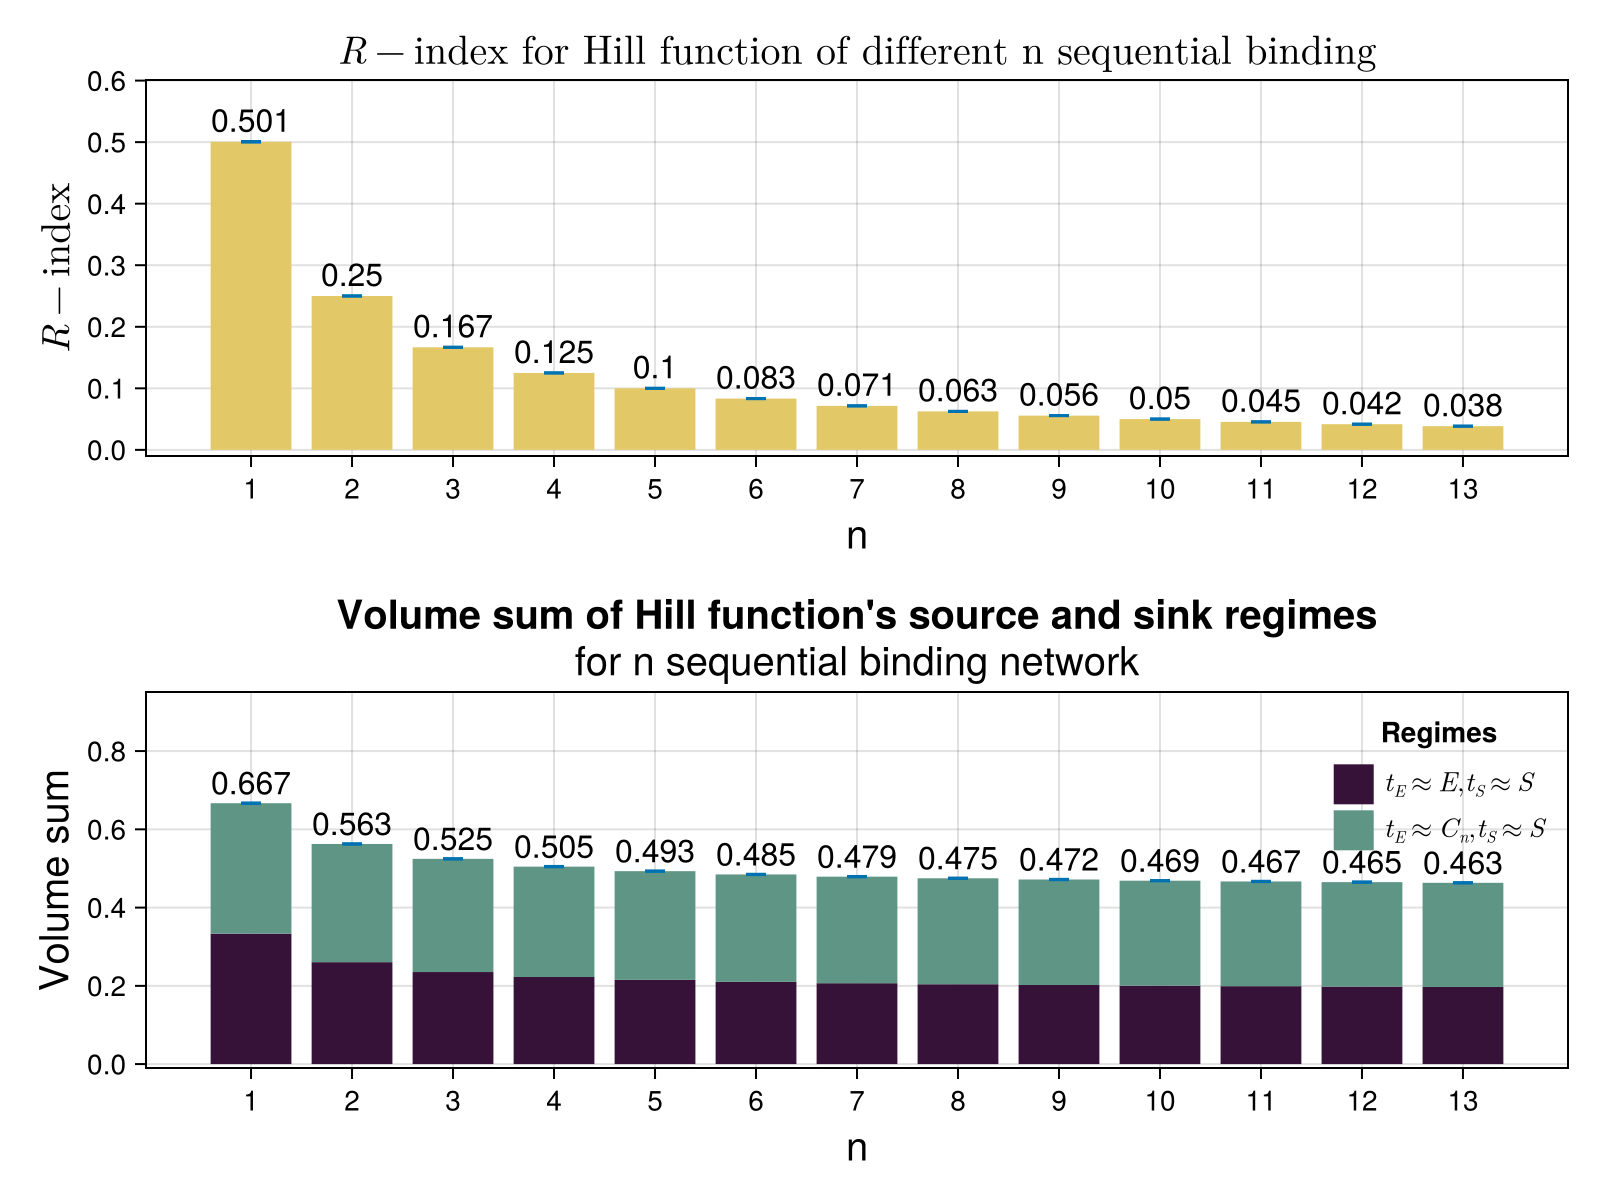

CairoMakie.Screen{IMAGE}


In [38]:
F=Figure(size=(800,600))

txtsize = 20

ax = Axis(F[1,1]; 
    xlabel="n", 
    ylabel=L"R\text{-index}", 
    xticks=1:13, 
    title=L"R\text{-index for Hill function of different n sequential binding}",
    titlesize = txtsize,
    xlabelsize = txtsize,
    ylabelsize = txtsize
)
barplot!(ax, 1:13, getindex.(r_idx, 1),color = "#E2C867")
errorbars!(ax, 1:13, getindex.(r_idx, 1), getindex.(r_idx, 2),getindex.(r_idx, 2),whiskerwidth = 10)
text!(ax, 1:13, getindex.(r_idx, 1) .+ 0.005; text=string.(round.(getindex.(r_idx, 1), digits=3)), fontsize=txtsize*.8, align = (:center, :bottom))
ylims!(ax, -0.01,0.601)


ax2 = Axis(F[2,1]; 
    xlabel="n", 
    ylabel="Volume sum", 
    xticks=1:13, 
    title="Volume sum of Hill function's source and sink regimes",
    subtitle = "for n sequential binding network",
    titlesize = txtsize,
    xlabelsize = txtsize,
    subtitlesize = txtsize,
    ylabelsize = txtsize
    )    
labels = [L"t_E\approx E, t_S \approx S", L"t_E\approx C_n, t_S \approx S"]
bp = barplot!(ax2, vl[1],vl[2]; stack=vl[3], color=vl[3],colorrange=(1,2),colormap = :glasgowS,
    label = [label => (;color = i) for (i, label) in enumerate(labels)])

errorbars!(ax2, 1:13, tot_hgt, tot_errs, tot_errs; whiskerwidth=10)
text!(ax2, 1:13, tot_hgt .+ 0.005; text=string.(round.(tot_hgt, digits=3)), fontsize=txtsize*.8, align = (:center, :bottom))
ylims!(ax2, -0.01,0.951)

axislegend(ax2,"Regimes";framevisible = false, backgroundcolor = :white)

display(F)

In [39]:
save("/mnt/e/Pictures/Hill_sequential_n.pdf", F)

CairoMakie.Screen{PDF}


In [28]:
delta = sqrt.(1 ./ (tot_hgt[1:end-1].- tot_hgt[2:end]))

12-element Vector{Float64}:
  3.097802308307614
  5.129509802731714
  7.087065754330354
  9.311282354804389
 10.885144904565452
 13.331990510599315
 15.515425784066748
 17.761175899813544
 18.276364010805334
 22.565413479846587
 24.234307359193036
 23.774864897465072

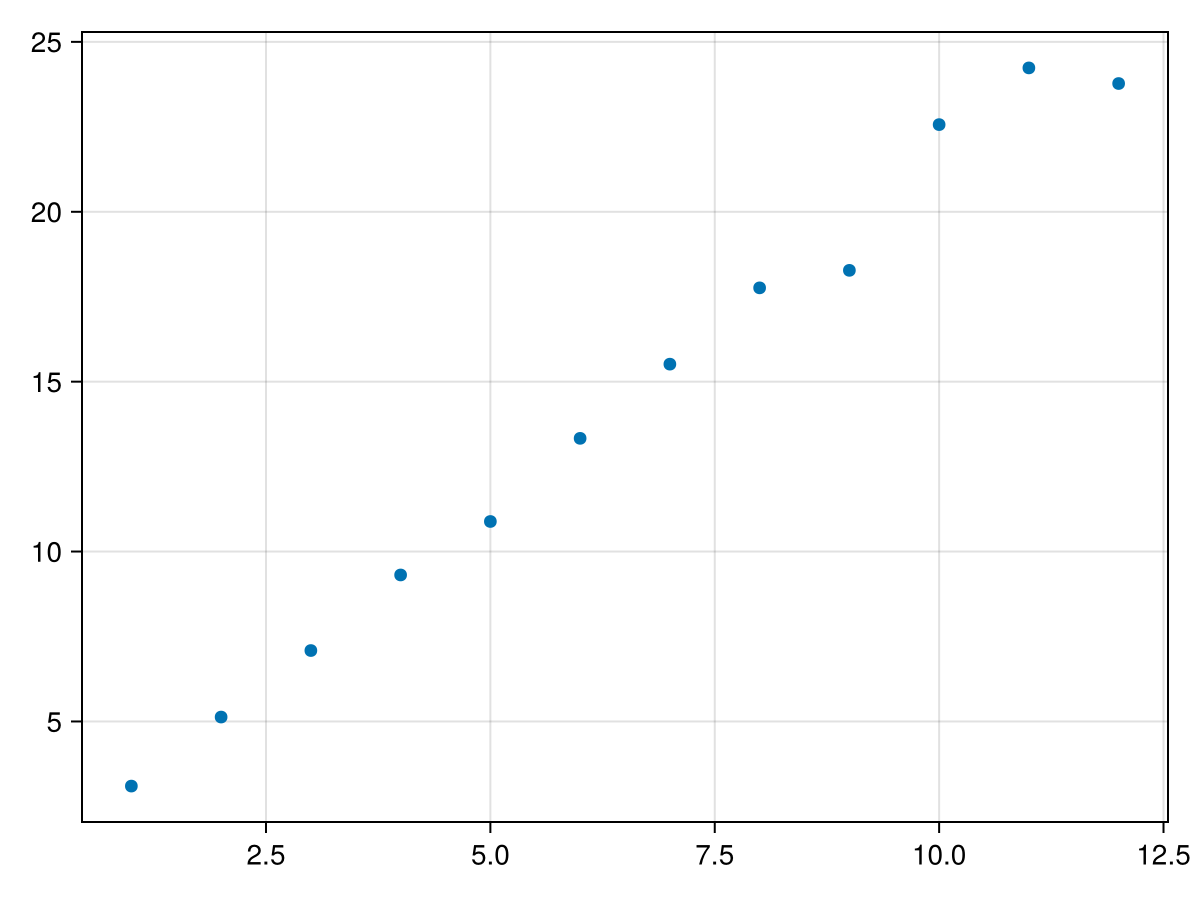

In [23]:
plot(sqrt.(-1 ./ delta))

In [81]:
hill(1)

---------------------Start finding all vertices, it may takes a while.--------------------
Finished, with 4 vertices found and 4 asymptotic vertices.

-------------Start calculating nullity for each vertex, it also takes a while.------------
1.Building Nρ_inv cache in parallel...
2.Calculating nullity for each vertex in parallel...
3.Storing all vertices information...
Done.
----------Binding Network Summary:-------------
Number of species (n): 3
Number of conserved quantities (d): 2
Number of reactions (r): 1
L matrix: [1 0 1; 0 1 1]
N matrix: [1 1 -1]
Direction of binding reactions: backward
Catalysis involved: No
Regimes constructed: Yes
Number of regimes: 4
  - Invertible + Asymptotic: 3
  - Singular +  Asymptotic: 1
  - Invertible +  Non-Asymptotic: 0
  - Singular +  Non-Asymptotic: 0
-----------------------------------------------


In [84]:
function hill(n)
    function hill_N(hill_n)
        N = zeros(Int, hill_n,hill_n+2)
        N[:,1] .= 1
        for i in 1:hill_n
            N[i,i+1] = 1
            N[i,i+2] = -1
        end
        return N
    end

    N = hill_N(n)
    x_syms = Num.(vcat([:S, :E], name_converter("C".*repr.(1:n))))
    q_syms = [:tS, :tE]
    K_syms = Num.(name_converter("K".* repr.(1:n)))
    model = Bnc(N=N, x_sym=x_syms, q_sym=q_syms, K_sym=K_syms)
    find_all_vertices!(model)
    return (length(get_vertices(model,singular=false,asymptotic=true)), 
            length(get_vertices(model,singular=true,asymptotic=true)),
            length(get_vertices(model,singular=false,asymptotic=false)),
            length(get_vertices(model,singular=true,asymptotic=false))
    )
end

hill (generic function with 1 method)

In [85]:
rgm_num = [hill(n) for n in 1:13]

---------------------Start finding all vertices, it may takes a while.--------------------
Finished, with 4 vertices found and 4 asymptotic vertices.

-------------Start calculating nullity for each vertex, it also takes a while.------------
1.Building Nρ_inv cache in parallel...
2.Calculating nullity for each vertex in parallel...
3.Storing all vertices information...
Done.
---------------------Start finding all vertices, it may takes a while.--------------------
Finished, with 8 vertices found and 7 asymptotic vertices.

-------------Start calculating nullity for each vertex, it also takes a while.------------
1.Building Nρ_inv cache in parallel...
2.Calculating nullity for each vertex in parallel...
3.Storing all vertices information...
Done.
---------------------Start finding all vertices, it may takes a while.--------------------
Finished, with 13 vertices found and 10 asymptotic vertices.

-------------Start calculating nullity for each vertex, it also takes a while.------------


13-element Vector{NTuple{4, Int64}}:
 (3, 1, 0, 0)
 (5, 2, 1, 0)
 (7, 3, 3, 0)
 (9, 4, 6, 0)
 (11, 5, 10, 0)
 (13, 6, 15, 0)
 (15, 7, 21, 0)
 (17, 8, 28, 0)
 (19, 9, 36, 0)
 (21, 10, 45, 0)
 (23, 11, 55, 0)
 (25, 12, 66, 0)
 (27, 13, 78, 0)

In [74]:
function hill_N(hill_n)
        N = zeros(Int, hill_n,hill_n+2)
        N[:,1] .= 1
        for i in 1:hill_n
            N[i,i+1] = 1
            N[i,i+2] = -1
        end
        return N
    end

hill_N (generic function with 1 method)

----------Binding Network Summary:-------------
Number of species (n): 5
Number of conserved quantities (d): 2
Number of reactions (r): 3
L matrix: sparse([1, 2, 1, 2, 1, 2, 1, 2], [1, 2, 3, 3, 4, 4, 5, 5], [1, 1, 1, 1, 2, 1, 3, 1], 2, 5)
N matrix: sparse([1, 2, 3, 1, 1, 2, 2, 3, 3], [1, 1, 1, 2, 3, 3, 4, 4, 5], [1, 1, 1, 1, -1, 1, -1, 1, -1], 3, 5)
Direction of binding reactions: backward
Catalysis involved: No
Regimes constructed: No
-----------------------------------------------

In [82]:
model.N

3×5 SparseMatrixCSC{Int64, Int64} with 9 stored entries:
 1  1  -1   ⋅   ⋅
 1  ⋅   1  -1   ⋅
 1  ⋅   ⋅   1  -1

In [95]:
using BindingAndCatalysis.Polyhedra

In [98]:
n=2

2

In [135]:
n=1

1

In [144]:
model = Bnc(N=hill_N(n))

rgms = let
    rgms = Any[]
    for rgm in get_regimes(model; singular=false)
        H = get_H(rgm)
        if H[model.n,1] == n && H[model.n,2] == 1
            push!(rgms, rgm)
        elseif H[model.n,1] == 0 && H[model.n,2] == 1
            push!(rgms, rgm)
        end
    end
    rgms
end

summary(model)
# @assert length(rgms) == 2 
# ps = get_polyhedron.(rgms)
# p = intersect(ps...)
# p_e = eliminate(p, BitSet(1)) # eliminate tS
# push!(ps, p_e)

n+=1
# vs = [calc_volume(ps[1:2]); calc_volume(ps[3])]


[ Info: ---------------------Start finding all regimes--------------------
[ Info: Finished, with 43 regimes found and 22 asymptotic regimes.
[ Info: 2.Building x-neighbor regime graph...
[ Info: 3.Building regime objects...
[ Info: 4.Propagating affine data and deferred nullity labels...


----------Binding Network Summary:-------------
Number of species (n): 9
Number of conserved quantities (d): 2
Number of reactions (r): 7
L matrix: sparse([1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2], [1, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9], [1, 1, 1, 1, 2, 1, 3, 1, 4, 1, 5, 1, 6, 1, 7, 1], 2, 9)
N matrix: sparse([1, 2, 3, 4, 5, 6, 7, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7], [1, 1, 1, 1, 1, 1, 1, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9], [1, 1, 1, 1, 1, 1, 1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1], 7, 9)
Direction of binding reactions: backward
Catalysis involved: No
Regimes constructed: Yes
Number of regimes: 43
  - Invertible + Asymptotic: 15
  - Singular +  Asymptotic: 7
  - Invertible +  Non-Asymptotic: 21
  - Singular +  Non-Asymptotic: 0
-----------------------------------------------


[ Info: 5.Calculating qK change directions on the regime graph...
[ Info: Finished.


8

In [120]:
n+=1

6

In [111]:
dim(p)

3

In [83]:
show_conservation(model)

2-element Vector{Symbolics.Equation}:
 q₁ ~ x₁ + x₃ + 2x₄ + 3x₅
 q₂ ~ x₂ + x₃ + x₄ + x₅

In [79]:
show_expression_x(model, 8)

5-element Vector{Symbolics.Equation}:
 x₁ ~ ((1//2)*K₂*q₁) / q₂
 x₂ ~ (2K₁*(q₂^(2//1))) / (K₂*q₁)
 x₃ ~ q₂
 x₄ ~ (1//2)*q₁
 x₅ ~ (K₂*(q₁^(2//1))) / (4K₃*q₂)

In [39]:
function hill_val(n)
    function hill_N(hill_n)
        N = zeros(Int, hill_n,hill_n+2)
        N[:,1] .= 1
        for i in 1:hill_n
            N[i,i+1] = 1
            N[i,i+2] = -1
        end
        return N
    end

    N = hill_N(n)
    x_syms = Num.(vcat([:S, :E], name_converter("C".*repr.(1:n))))
    q_syms = [:tS, :tE]
    K_syms = Num.(name_converter("K".* repr.(1:n)))
    model = Bnc(N=N, x_sym=x_syms, q_sym=q_syms, K_sym=K_syms)
    perm1 = [1,2]
    perm2 = [1,n+2]

    P1,P01 = _calc_P_and_P0(model, perm1)
    P2,P02 = _calc_P_and_P0(model, perm2)

    Cx1, C0x1 = _calc_C_C0_x(model, perm1)
    Cx2, C0x2 = _calc_C_C0_x(model, perm2)

    M1 = vcat(P1, N)
    M10 = vcat(P01, zeros(size(N,1)))
    M2 = vcat(P2, N)
    M20 = vcat(P02, zeros(size(N,1)))

    H1 = inv(Array(M1))
    H10 = -H1 * M10
    H2 = inv(Array(M2))
    H20 = -H2 * M20

    Cqk1 = Cx1 * H1
    C0qk1 = Cx1 * H10 + C0x1
    Cqk2 = Cx2 * H2
    C0qk2 = Cx2 * H20 + C0x2

    p1 = get_polyhedra(Cqk1,C0qk1)
    p2 = get_polyhedra(Cqk2,C0qk2)
    p = [p1,p2]
    
    # println("time to eliminate variables: ")
    # p = eliminate(p, BitSet(1))
    # detecthlinearity!(p)
    # removevredundancy!(p)

    # obs_x = n+2

    # grh = SISO_graph(model, :tS)
    # pths = find_reaction_order_for_path(grh, obs_x; deduplicate=true, keep_singular=true, keep_nonasymptotic=true)
    # vals = ones(Float64, length(pths))
    # @show pths
    # pth_idx = findall(x-> x==[Float64(n),0.0], pths)
    # # print("$pth_idx")
    # @assert length(pth_idx) == 1 
    # idx = pth_idx[1]
    # println("Found path index: ", idx)
    # x = show_condition_qK(grh, idx; log_space=false)
    # display(x)

    # a,b = get_expression_for_path(grh, idx, obs_x; log_space=false)
    # display.(a)
    # println("-"^100)
    # display.(b)

    return calc_volume(p; rel_tol=0.001, asymptotic=true)
end

hill_val (generic function with 1 method)

In [9]:
f(lgSt,lgEt=5,lgK=1)=begin
    Et = exp10(lgEt)
    St = exp10(lgSt)
    K = exp10(lgK)
    return log10(1/maximum([1/Et, St/(K*Et)]))
end

f (generic function with 3 methods)

In [10]:
using CairoMakie

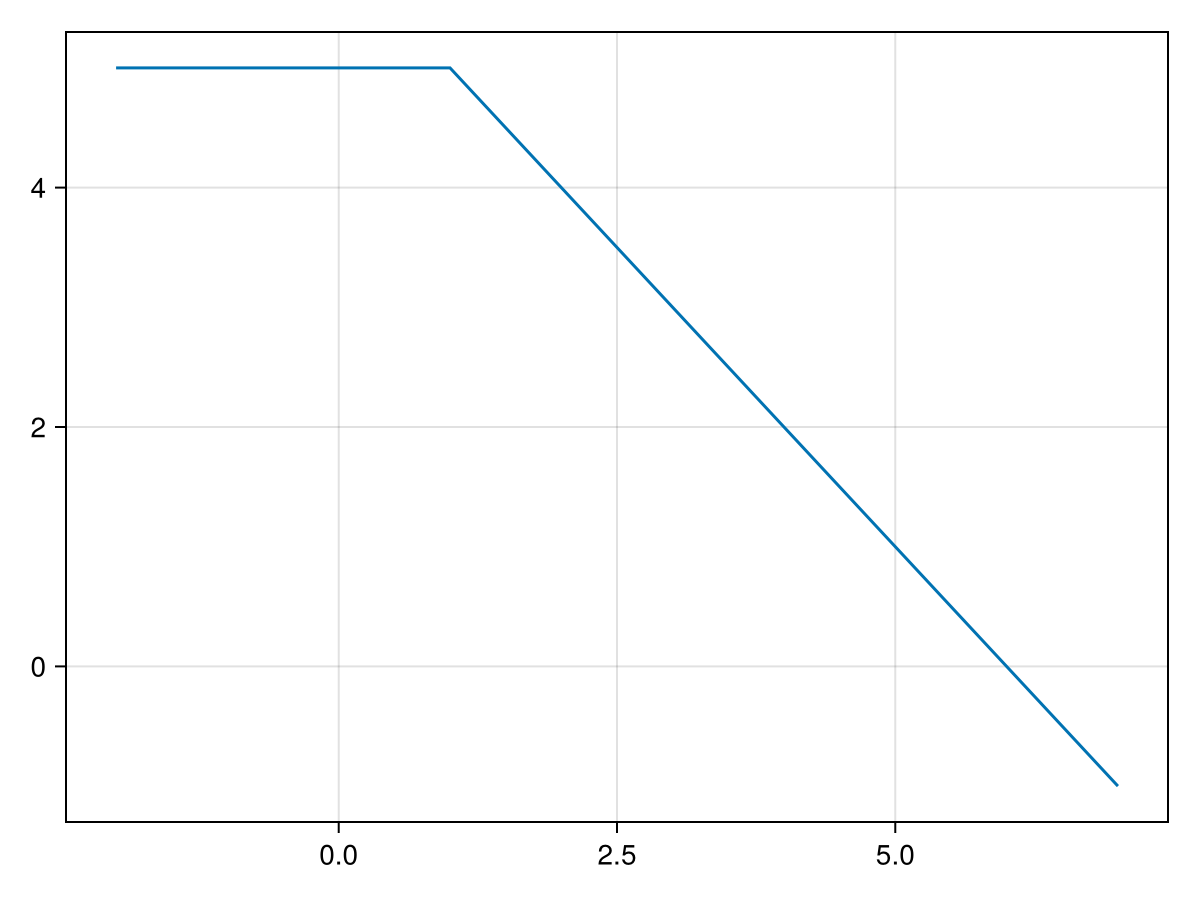

In [11]:
lgSt = range(-2,7,1000)
lgE = f.(lgSt)

F = lines(lgSt,lgE)